## 1) Autor:
## Brayan Alexis De Sousa Lora 	C.C.: 1.127.605.605


-----------------------------------------------------------------------------------------------

## 2) Descripción corta del dataset:
### - La fuente de los datos corresponde a la encuesta Behavioral Risk Factor Surveillance System (BRFSS), desarrollada por el Centers for Disease Control and Prevention (CDC) en el año 2015. Este conjunto de datos original contiene aproximadamente 441.456 registros. A partir de este, se realizó un proceso de limpieza y adaptación para su uso en la competición de Kaggle denominada “Diabetes Prediction Competition (TFUG CHD Nov 2022)”, obteniéndose un dataset final de aproximadamente 100.000 registros.



---------------------------------------------------------------------------------------------------

## 3) Objetivo a desarrollar:

### - Diseñar e implementar modelos de aprendizaje automático supervisado para la predicción temprana de la diabetes, utilizando variables demográficas, clínicas y de hábitos de vida, con el fin de estimar la probabilidad de desarrollar la enfermedad y apoyar la toma de decisiones preventivas en salud.



----------------------------------------------------------------------------------------------------------------------------------

## 4) Resumen del proceso realizado:




### A.	Preprocesamiento de datos

Se aplicaron las siguientes técnicas:


*   Limpieza de datos y tratamiento de valores faltantes
*   Detección y análisis de valores atípicos (outliers)
*   Análisis exploratorio de datos (EDA)
*   Estadística descriptiva para la caracterización de variables
*   Escalado de variables numéricas mediante normalización
*   Balanceo de clases
*   División del dataset en conjuntos de entrenamiento y prueba

### B.	Modelos de aprendizaje automático

Se implementaron y evaluaron diferentes modelos de clasificación supervisada:

*   Regresión Logística
*   Clasificador Bayesiano
*   k-Nearest Neighbors (KNN)
*   Máquinas de Soporte Vectorial (SVM)
*   Árboles de Decisión
*   Random Forest
*   AdaBoost  
*   Gradient Boosting
*   XGBoost

Para cada modelo se realizó el ajuste de hiperparámetros con el fin de optimizar su desempeño.

### C.	Criterios de evaluación

El desempeño de los modelos se evaluó utilizando métricas de clasificación, entre las cuales se incluyen:

*   Exactitud (Accuracy)
*   Precisión (Precision)
*   Sensibilidad (Recall)
*   F1-score
*   Matriz de confusión

--------------------------------------------------------------
# EXPERIMENTO 2

##-- SE APLICARON TÉCNICAS DE REDUCCIÓN DE DIMENSIÓN:
Se aplicaron métodos de Selección Secuencial de Características (SSF - Sequential Feature Selection); en particular, se utilizó la técnica de Selección Secuencial hacia Adelante (SFFS - Sequential Forward Feature Selection).

---------------------------------------------------------------------------------------------

## 5) Desarrollo de experimentos:

## 1. Librerías y configuraciones previas

In [1]:
# Tratamiento de datos
# ==============================================================================
import pandas as pd
import numpy as np
import math as math
import joblib
from joblib import load


# Preprocesado y modelado
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.neighbors import LocalOutlierFactor
from imblearn.under_sampling import RandomUnderSampler

# Escalar Variables
from sklearn.preprocessing import MinMaxScaler

# Creacion de los modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import make_scorer, f1_score
from sklearn.metrics import accuracy_score, recall_score, f1_score, roc_auc_score

# EvaluarModelos
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve
import sklearn.metrics as metrics
from sklearn import svm
from sklearn.model_selection import GridSearchCV

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

# Modelos
import statsmodels.api as sm
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB

#Creación de modelo
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import plot_tree
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
from mlxtend.feature_selection import SequentialFeatureSelector as SFS


#configuracion de hiperparámetros
from sklearn.model_selection import GridSearchCV

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

## 2. Cargar el Dataset

In [2]:
file_id = "1dAP_mh1zqEEe4DJ2MxFISv6Fc86lD8w0"
ruta = f"https://drive.google.com/uc?id={file_id}"

In [3]:
# Se crea un dataframe df con los datos obtenidos de archivo de entrada
df = pd.read_csv(ruta)

In [4]:
# Se revisan las dimensiones
df.shape

(80692, 18)

In [5]:
# Se revisan las columnas, nulos y tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80692 entries, 0 to 80691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   80692 non-null  float64
 1   Sex                   80692 non-null  float64
 2   HighChol              80692 non-null  float64
 3   CholCheck             80692 non-null  float64
 4   BMI                   80692 non-null  float64
 5   Smoker                80692 non-null  float64
 6   HeartDiseaseorAttack  80692 non-null  float64
 7   PhysActivity          80692 non-null  float64
 8   Fruits                80692 non-null  float64
 9   Veggies               80692 non-null  float64
 10  HvyAlcoholConsump     80692 non-null  float64
 11  GenHlth               80692 non-null  float64
 12  MentHlth              80692 non-null  float64
 13  PhysHlth              80692 non-null  float64
 14  DiffWalk              80692 non-null  float64
 15  Diabetes           

In [6]:
# Se revisan las 2 primeras filas
df.head(2)

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Diabetes,Hypertension,Stroke
0,4.0,1.0,0.0,1.0,26.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,5.0,30.0,0.0,0.0,1.0,0.0
1,12.0,1.0,1.0,1.0,26.0,1.0,0.0,0.0,1.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,1.0,1.0


In [7]:
# Obtenemos el resumen estadístico de las columnas numéricas
df.describe()

,Age,Sex,HighChol,CholCheck,BMI,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Diabetes,Hypertension,Stroke
count,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000,80692.000000
mean,8.571841,0.481919,0.518750,0.969687,29.897747,0.494894,0.141823,0.680861,0.588757,0.777735,0.041516,2.854583,3.618959,5.807763,0.257869,0.509319,0.545903,0.062732
std,2.852525,0.499676,0.499651,0.171448,7.365230,0.499977,0.348871,0.466146,0.492062,0.415771,0.199481,1.106053,7.995605,10.026168,0.437464,0.499916,0.497892,0.242482
min,1.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,9.000000,0.000000,1.000000,1.000000,29.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,11.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,1.000000,0.000000
max,13.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,1.000000,1.000000


## 3. Limpieza de datos (Data Cleaning):

In [8]:
# Revisamos por valores faltantes
print('Datos faltantes por columna:')
print(df.isnull().sum())

Datos faltantes por columna:
Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Diabetes                0
Hypertension            0
Stroke                  0
dtype: int64


### * Tenemos variables Binarias, Ordinales y Numericas continuas, no contamos con categóricas.

## 4. Visualización de datos

### Variables de entrada

In [9]:
# Lista de variables numéricas binarias
binary_cols = [col for col in df.columns
               if set(df[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = df[binary_cols]
X_bin.head(2)

,Sex,HighChol,CholCheck,Smoker,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,DiffWalk,Hypertension,Stroke
0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0


In [10]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in df.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = df[num_cols]
X_num.head(2)

,Age,BMI,GenHlth,MentHlth,PhysHlth
0,4.0,26.0,3.0,5.0,30.0
1,12.0,26.0,3.0,0.0,0.0


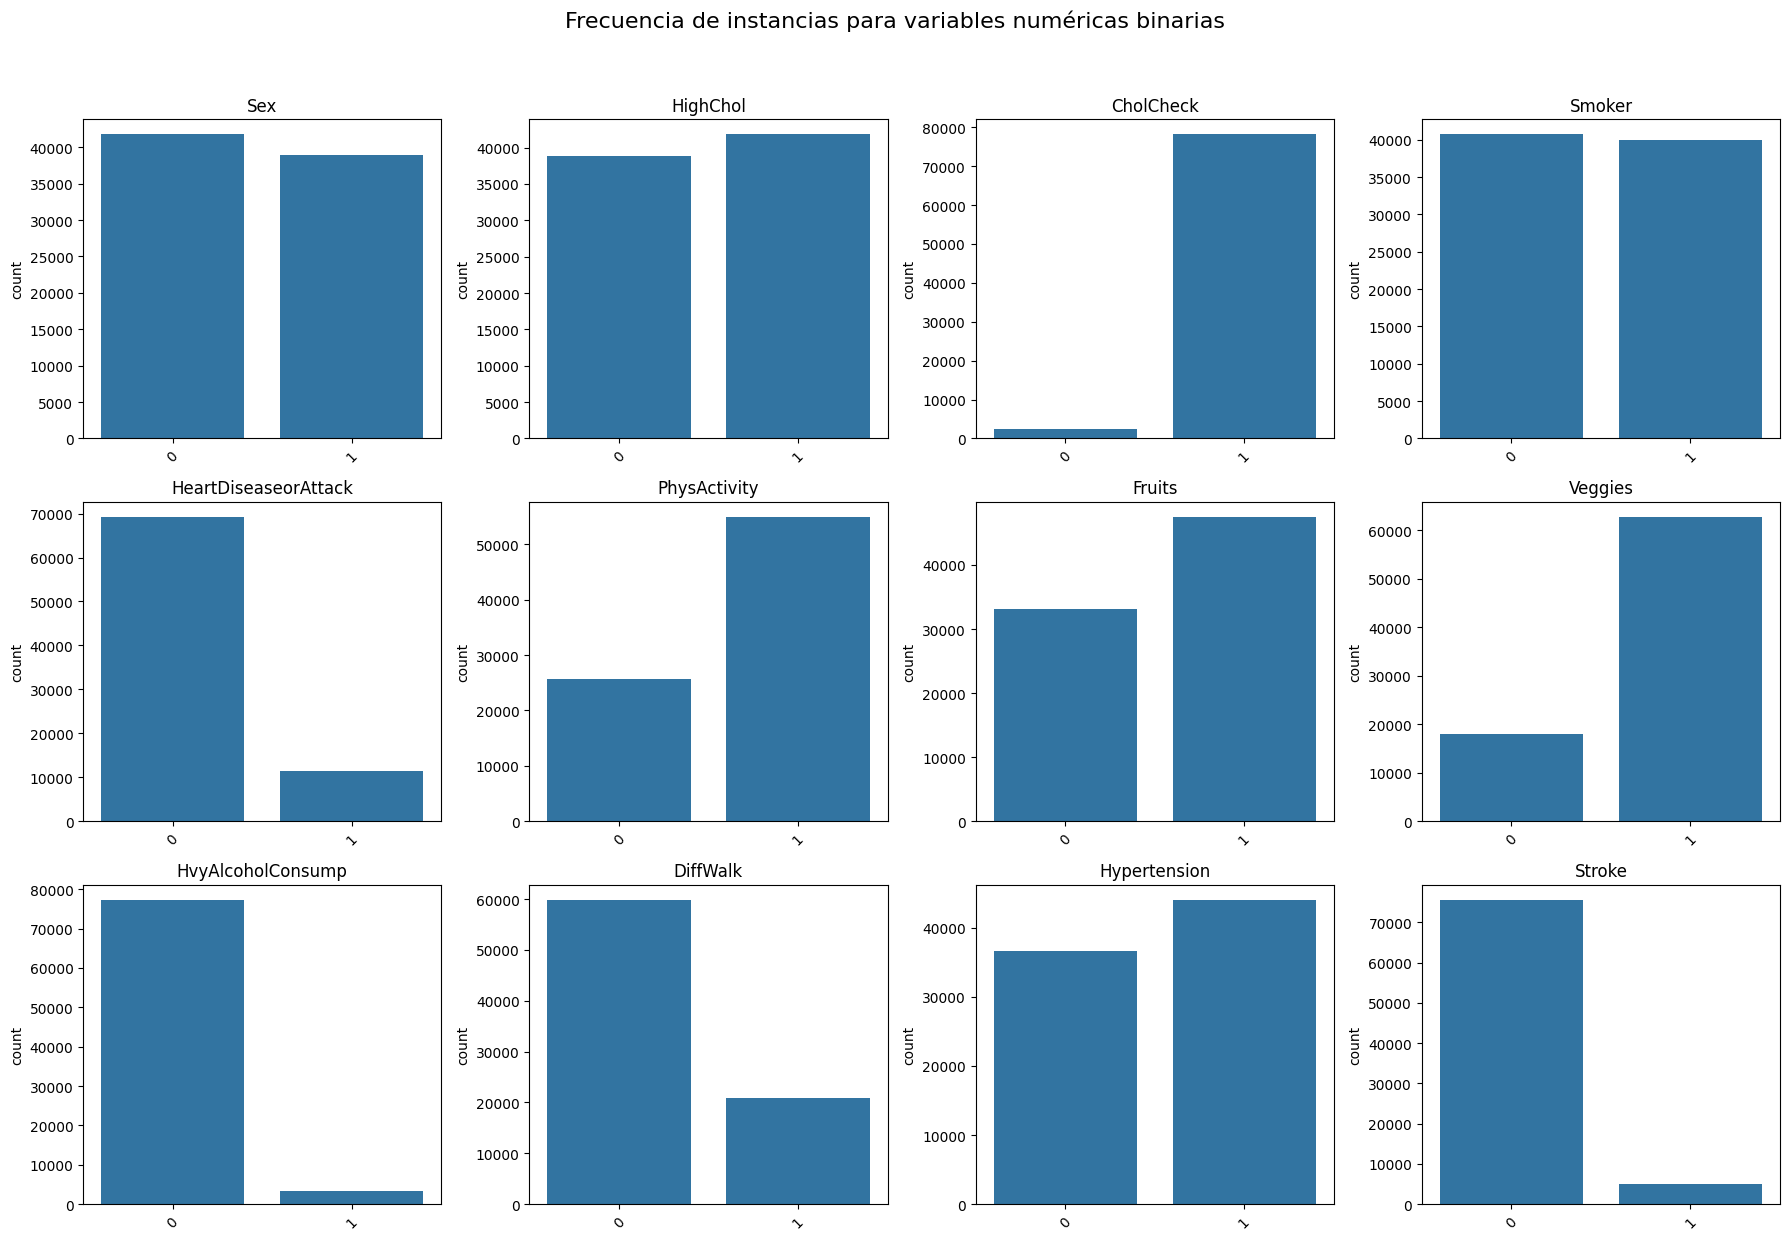

In [11]:
# Visualización de frecuencia de instancias para variables numéricas binarias

# Asegurar tipo entero
df[binary_cols] = df[binary_cols].astype(int)

n = len(binary_cols)
rows = math.ceil(n / 4)

fig, axes = plt.subplots(rows, 4, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(data=df, x=col, order=[0,1], ax=axes[i])

    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Frecuencia de instancias para variables numéricas binarias', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

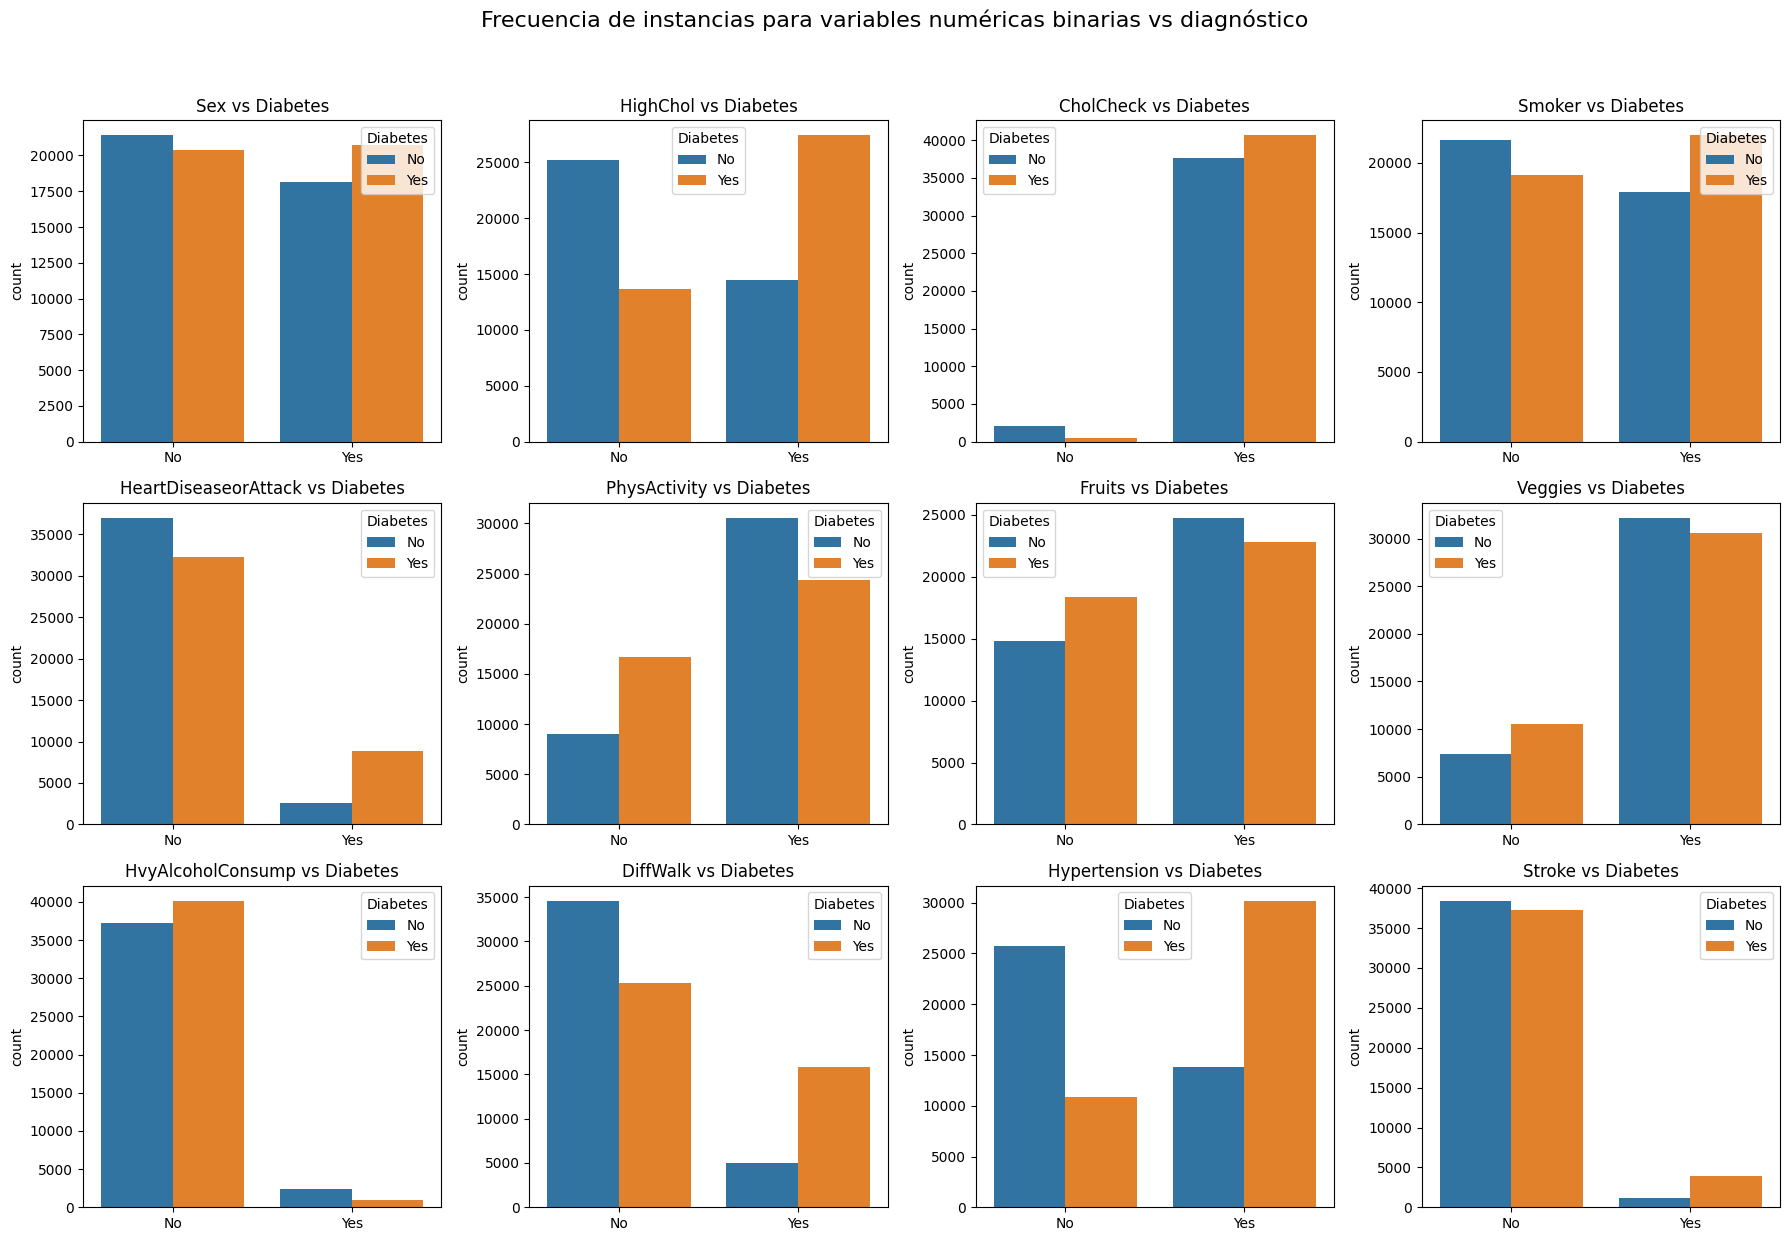

In [12]:
# Visualización de frecuencia de instancias para variables numéricas binarias vs diagnóstico

# Copia temporal del DataFrame
df_plot = df.copy()

# Asegurar tipo int
df_plot[binary_cols] = df_plot[binary_cols].astype(int)

# Mapear target
df_plot['Diabetes'] = df_plot['Diabetes'].map({0: 'No', 1: 'Yes'})

# Gráfico
n = len(binary_cols)
rows = math.ceil(n / 4)

fig, axes = plt.subplots(rows, 4, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(binary_cols):

    # Evitar graficar el target contra sí mismo
    if col == 'Diabetes':
        continue

    sns.countplot(
        data=df_plot,
        x=col,
        hue='Diabetes',
        order=[0,1],
        ax=axes[i]
    )

    axes[i].set_title(f'{col} vs Diabetes')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('count')
    axes[i].set_xticklabels(['No', 'Yes'])

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Frecuencia de instancias para variables numéricas binarias vs diagnóstico', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

In [13]:
# Distribución de cada variable numérica binaria en el conjunto de datos

for col in binary_cols:
    print("="*5 + f" {col} " + "="*20)
    print(df[col].value_counts())
    print()

===== Sex ====================
Sex
0    41805
1    38887
Name: count, dtype: int64

===== HighChol ====================
HighChol
1    41859
0    38833
Name: count, dtype: int64

===== CholCheck ====================
CholCheck
1    78246
0     2446
Name: count, dtype: int64

===== Smoker ====================
Smoker
0    40758
1    39934
Name: count, dtype: int64

===== HeartDiseaseorAttack ====================
HeartDiseaseorAttack
0    69248
1    11444
Name: count, dtype: int64

===== PhysActivity ====================
PhysActivity
1    54940
0    25752
Name: count, dtype: int64

===== Fruits ====================
Fruits
1    47508
0    33184
Name: count, dtype: int64

===== Veggies ====================
Veggies
1    62757
0    17935
Name: count, dtype: int64

===== HvyAlcoholConsump ====================
HvyAlcoholConsump
0    77342
1     3350
Name: count, dtype: int64

===== DiffWalk ====================
DiffWalk
0    59884
1    20808
Name: count, dtype: int64

===== Hypertension =========

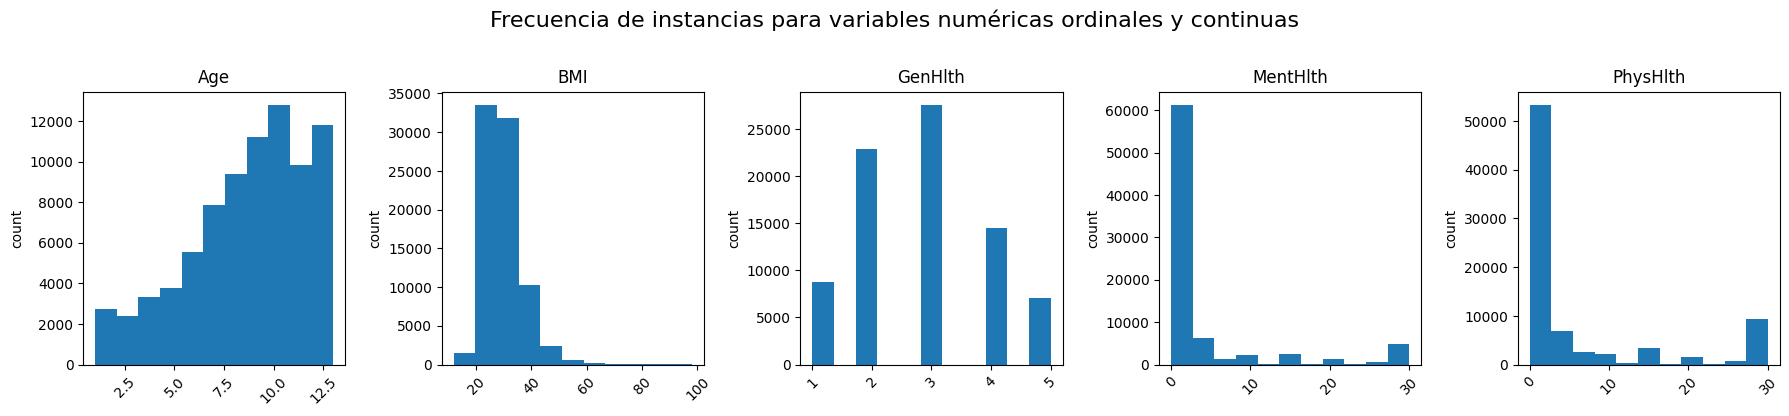

In [14]:
# Visualización de frecuencia de instancias para variables numéricas ordinales y continuas

n = len(num_cols)
rows = math.ceil(n / 5)
fig, axes = plt.subplots(rows, 5, figsize=(18, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]

    data = df[col].dropna()

    # Bins dinámicos
    bins = np.linspace(data.min(), data.max(), 12)

    ax.hist(data, bins=bins)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('count')
    ax.tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Frecuencia de instancias para variables numéricas ordinales y continuas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

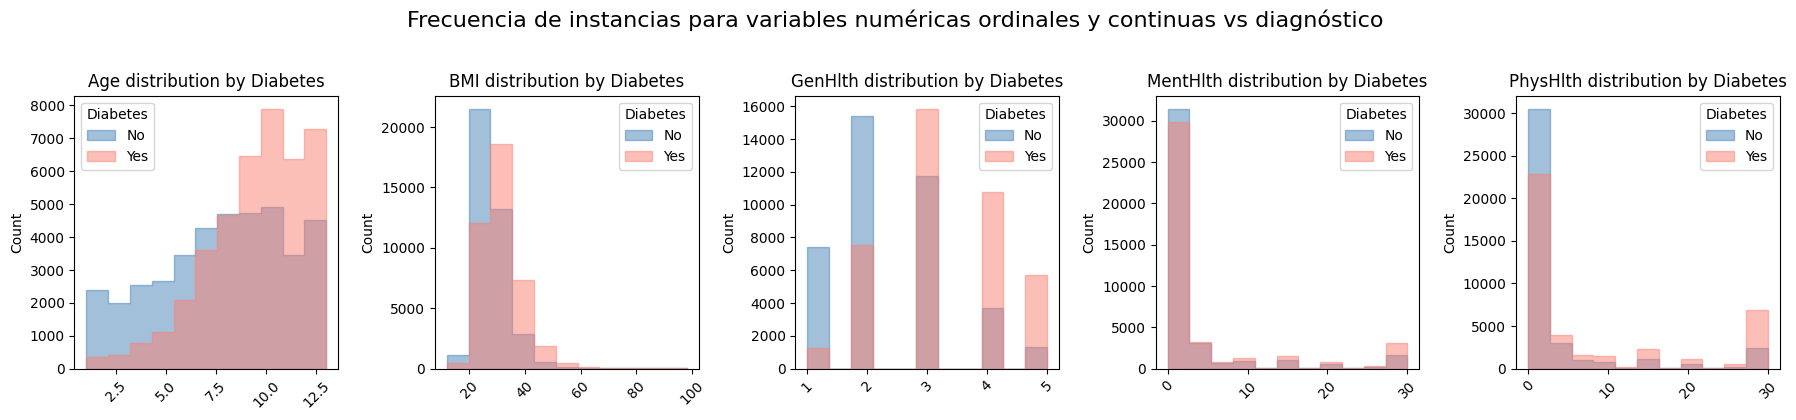

In [15]:
# Visualización de frecuencia de instancias para variables numéricas ordinales y continuas vs diagnóstico

n = len(num_cols)
rows = math.ceil(n / 5)
fig, axes = plt.subplots(rows, 5, figsize=(18, 4 * rows))
axes = axes.flatten()

target = "Diabetes"
cols = num_cols  # lista de columnas numéricas

# Colores y etiquetas para 0 y 1
colors = {0: 'steelblue', 1: 'salmon'}
order = [0, 1]
label_map = {0: 'No', 1: 'Yes'}


for i, col in enumerate(cols):
    bins = np.linspace(df[col].min(), df[col].max(), 12)
    for cat in order:
        subset = df.loc[df[target] == cat, col].dropna()
        axes[i].hist(subset, bins=bins, alpha=0.5,
                     color=colors[cat], edgecolor=colors[cat],
                     histtype='stepfilled', label=label_map[cat])

    axes[i].set_title(f"{col} distribution by {target}")
    axes[i].set_ylabel("Count")
    axes[i].legend(title=target)
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Frecuencia de instancias para variables numéricas ordinales y continuas vs diagnóstico', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

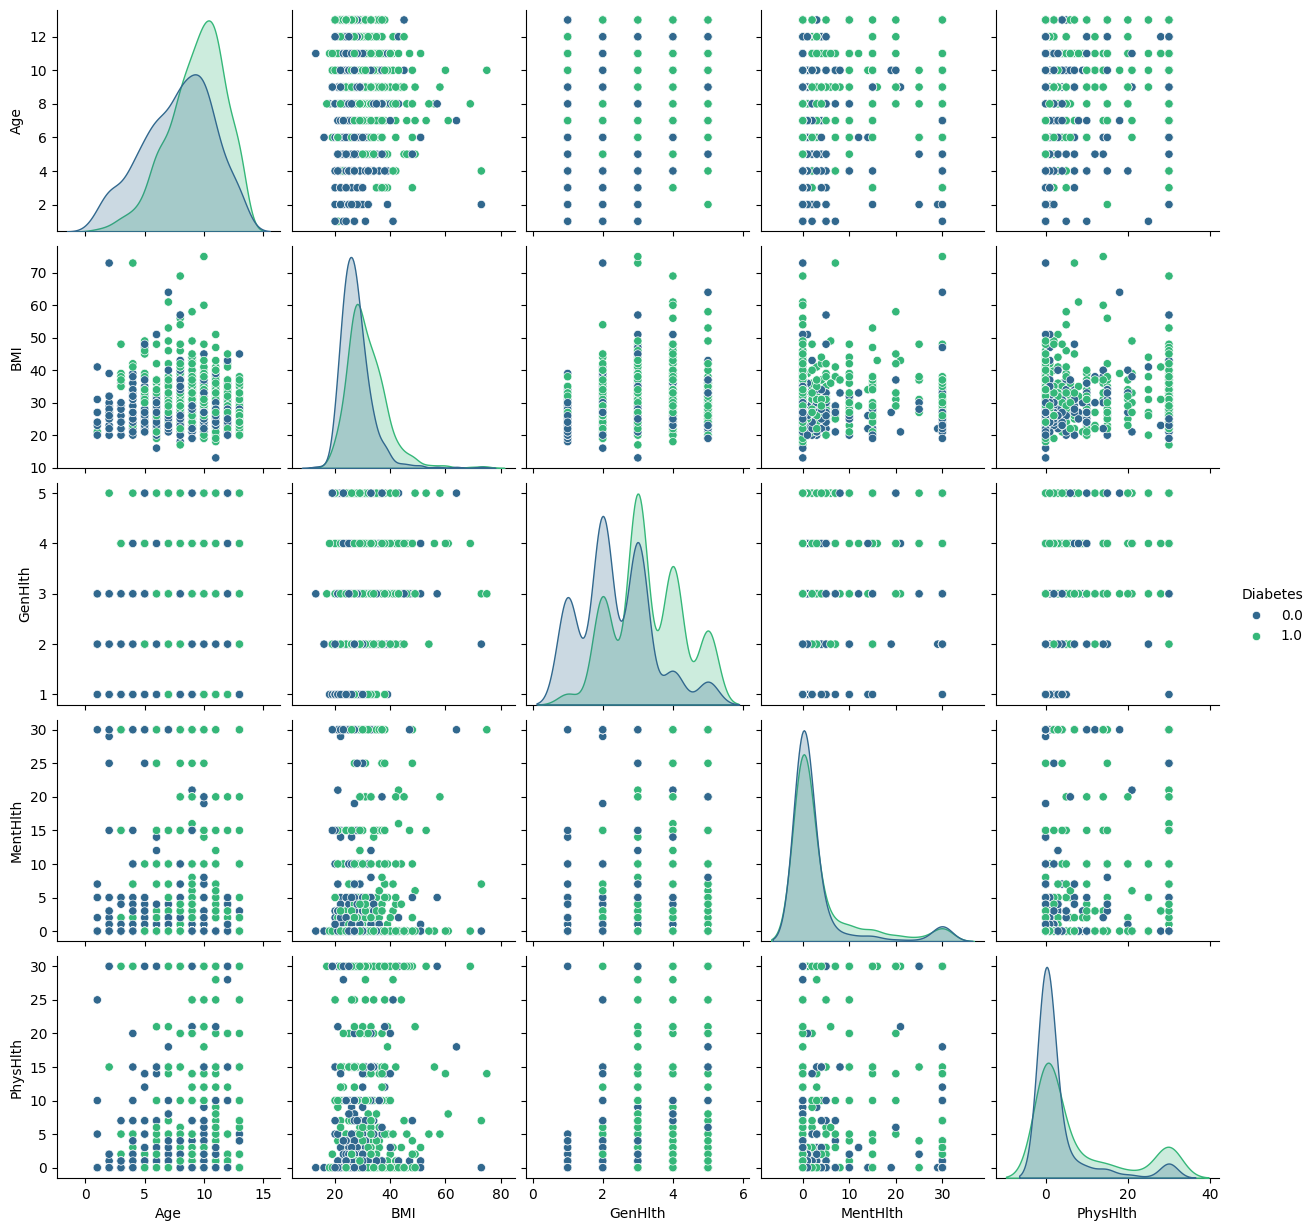

In [16]:
# Gráfico de dispersión entre cada par de variables numéricas ordinales y continuas con puntos coloreados según el diagnóstico
target = "Diabetes"

sns.pairplot(df.sample(1000, random_state=42), vars=num_cols, hue=target, diag_kind='kde', palette='viridis')
plt.show()

### Variable de salida

In [17]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
df['Diabetes'] = df['Diabetes'].astype(int)
df.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
1,41098
0,39594


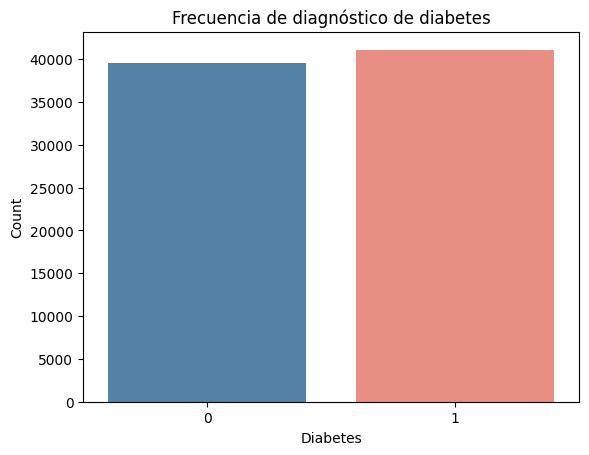

In [18]:
# Frecuencia de diagnóstico de diabetes
sns.countplot(x='Diabetes', data=df, palette={'0':'steelblue', '1':'salmon'})
plt.ylabel('Count')
plt.title('Frecuencia de diagnóstico de diabetes')
plt.show()

In [19]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
df.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
1,41098
0,39594


## 5. Preparación de datos

### * Imputaciones

No se requiere imputaciones, solo se realizará la verificación de la completitud

In [20]:
# Identificación de valores nulos para las variables numéricas binarias
for col in binary_cols:
    print (col, np.sum(pd.isnull(df[col])))

Sex 0
HighChol 0
CholCheck 0
Smoker 0
HeartDiseaseorAttack 0
PhysActivity 0
Fruits 0
Veggies 0
HvyAlcoholConsump 0
DiffWalk 0
Hypertension 0
Stroke 0


In [21]:
# Identificación de valores nulos para las variables numéricas ordinales y continuas
for col in num_cols:
    print (col, np.sum(pd.isnull(df[col])))

Age 0
BMI 0
GenHlth 0
MentHlth 0
PhysHlth 0


### * Datos de prueba

In [22]:
df = df.copy()
df = df.reset_index(drop=True)

In [23]:
# Porcentaje de filas para entrenamiento (90%)
percentage_first_part = 0.90

# DataFrame de entrenamiento (muestreo aleatorio)
df_f = df.sample(frac=percentage_first_part, random_state=123)

# DataFrame de prueba (restante)
df_p = df.drop(df_f.index)

### * Valores atípicos para las variables de entrada

In [24]:
print(df_f.shape)
print(df_f.index[:10])
print(df_f[num_cols].head())

(72623, 18)
Index([16049, 80592, 47068, 17203, 76977, 22186, 17736, 28949, 10165, 51923], dtype='int64')
        Age   BMI  GenHlth  MentHlth  PhysHlth
16049   9.0  32.0      4.0       0.0      30.0
80592  12.0  18.0      3.0       0.0      10.0
47068   9.0  34.0      3.0       0.0       0.0
17203  11.0  34.0      3.0       0.0       3.0
76977   8.0  30.0      5.0      15.0       4.0


In [25]:
# Utilización de LocalOutlierFactor con k vecinos para identificar valores atípicos
# en las variables de entrada

n = len(df_f)
k = int(n ** 0.5)  # raíz de n

# Crear un objeto LocalOutlierFactor con n_neighbors=k
lof = LocalOutlierFactor(n_neighbors=k, contamination=0.1)

# Identificar los valores atípicos por medio de lof
y_pred = lof.fit_predict(df_f[num_cols])

# Identificar los índices de los valores atípicos
outliers = y_pred == -1

print('Número de filas en el conjunto de datos: ', len(df_f))
print('Número de valores atípicos detectados: ', np.sum(outliers))
print('Indices de valores atípicos: ', df_f[outliers].index.tolist())

Número de filas en el conjunto de datos:  72623
Número de valores atípicos detectados:  7263
Indices de valores atípicos:  [80592, 27765, 1416, 16849, 77377, 3071, 2857, 28581, 58406, 56102, 70289, 37980, 159, 46122, 59166, 73110, 48360, 68502, 46369, 612, 10346, 6977, 3500, 68136, 59585, 46712, 54811, 65853, 79166, 15019, 18688, 6048, 20758, 48922, 29864, 56975, 20734, 25011, 63136, 22668, 76540, 58559, 28991, 67548, 78132, 79208, 74733, 17077, 13373, 26602, 66303, 35012, 48652, 30887, 35531, 1834, 69439, 55006, 72897, 80468, 2810, 69818, 75768, 56378, 68648, 64590, 51531, 72195, 42034, 61318, 75514, 73841, 19409, 5905, 56037, 77073, 35436, 11073, 38072, 63528, 76897, 1166, 22395, 68468, 46131, 78907, 26828, 42794, 1588, 19369, 56330, 21449, 68496, 11826, 47214, 72511, 63043, 13524, 30991, 55067, 59956, 21773, 80188, 22988, 46269, 26528, 31967, 23369, 23653, 33993, 56196, 54382, 19665, 25935, 19149, 12136, 55022, 9577, 43868, 21742, 79927, 3339, 61988, 71999, 68793, 20015, 25120, 2133

In [26]:
# Eliminar los valores atípicos del dataframe de entrenamiento
df_clean = df_f.loc[~outliers]

In [27]:
# Revisar dimensionalidad
df_clean.shape

(65360, 18)

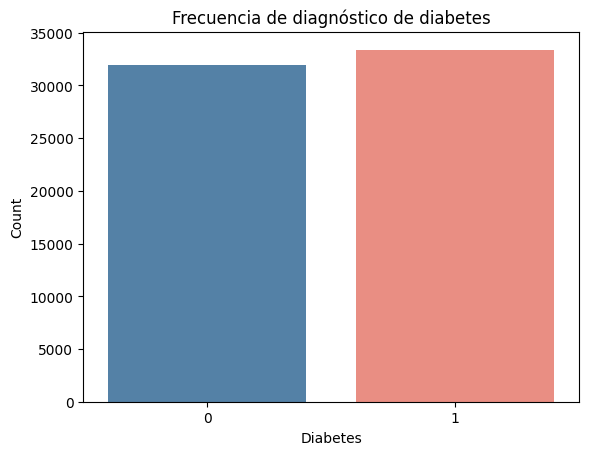

In [28]:
# Revisar de nuevo la frecuencia de diagnóstico de diabetes
sns.countplot(x='Diabetes', data=df_clean, palette={'0':'steelblue', '1':'salmon'})
plt.ylabel('Count')
plt.title('Frecuencia de diagnóstico de diabetes')
plt.show()

In [29]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
df_clean.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
1,33387
0,31973


### Debido a que el dataset está levemente desbalanceado, pero tenemos gran cantidad de datos en ambas clases, haremos undersampling (submuestreo) para reducir la cantidad de la clase mayoritaria para igualarla a la minoritaria. La ventaja es que no generamos datos aleatorios para los modelos y trabajaremos con datos reales.

### * Undersampling: eliminar parte de la clase mayoritaria

In [30]:
under = RandomUnderSampler(random_state=1)

X = df_clean.drop('Diabetes', axis=1)
y = df_clean['Diabetes']

X_resampled, y_resampled = under.fit_resample(X, y)

df_new = pd.concat([
    pd.DataFrame(X_resampled, columns=X.columns),
    pd.DataFrame(y_resampled, columns=['Diabetes'])
], axis=1)

In [31]:
# Revisar dimensionalidad
df_new.shape

(63946, 18)

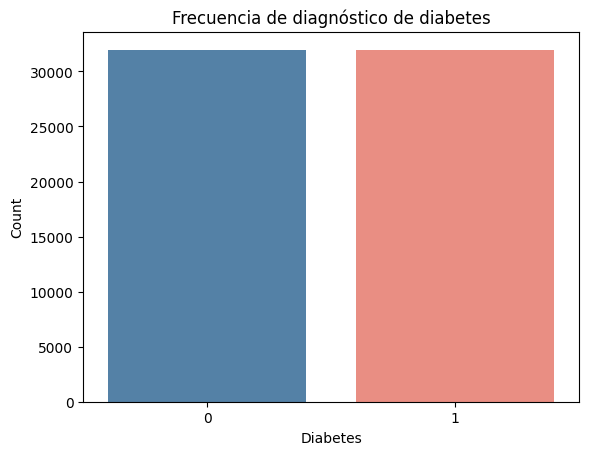

In [32]:
# Revisar de nuevo la frecuencia de diagnóstico de diabetes
sns.countplot(x='Diabetes', data=df_new, palette={'0':'steelblue', '1':'salmon'})
plt.ylabel('Count')
plt.title('Frecuencia de diagnóstico de diabetes')
plt.show()

In [33]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
df_new.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


In [34]:
# Separamos los datasets de entrenamiento para crear modelos y de prueba para evaluar modelos
df_new.to_csv("Diabetes_disease_Prep.csv", index=False)
df_p.to_csv("Diabetes_disease_Prue.csv", index=False)

## Aplicando SFFS - Sequential Forward Feature Selection

In [35]:
# 1. TRAIN / TEST

X_train = df_new.drop(columns=['Diabetes'])
y_train = df_new['Diabetes']

X_test = df_p.drop(columns=['Diabetes'])
y_test = df_p['Diabetes']


# 2. ESCALADO

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# 3. SAMPLE SOLO PARA SFFS

np.random.seed(42)
idx = np.random.choice(len(X_train_scaled), size=20000, replace=False)

X_sample = X_train_scaled[idx]
y_sample = y_train.iloc[idx]


# 4. SFFS


knn = KNeighborsClassifier(n_neighbors=4)

sffs = SFS(
    knn,
    k_features=(5, 12),
    forward=True,
    floating=True,
    #scoring="accuracy",
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

sffs.fit(X_sample, y_sample)

feat_idx = list(sffs.k_feature_idx_)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  17 out of  17 | elapsed:   36.5s finished
Features: 1/12[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:   17.5s finished
Features: 2/12[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  15 out of  15 | elapsed:   16.7s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   2 | elapsed:    2.8s finished
Features: 3/12[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  14 out of  14 | elapsed:   11.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:    3.1s finished
Features: 4/12[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concur

In [36]:
feature_names = X_train.columns

feat_idx = list(sffs.k_feature_idx_)

selected_features_names = [feature_names[i] for i in feat_idx]

print("Features seleccionadas por SFFS:")
print(selected_features_names)

Features seleccionadas por SFFS:
['HighChol', 'CholCheck', 'GenHlth', 'PhysHlth', 'Hypertension']


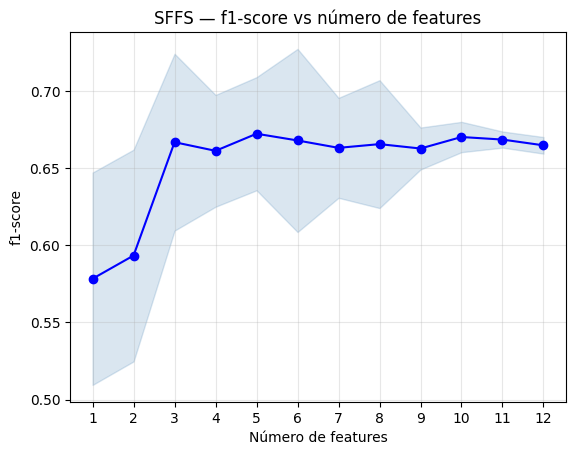

In [37]:
fig = plot_sfs(sffs.get_metric_dict(), kind='std_dev')

plt.title("SFFS — f1-score vs número de features")
plt.xlabel("Número de features")
plt.ylabel("f1-score")
plt.grid(True, alpha=0.3)
plt.show()

In [38]:
features_importantes = [
    'HighChol', 'CholCheck', 'GenHlth', 'PhysHlth', 'Hypertension'
]

In [39]:
df_new_sffs = df_new[features_importantes + ['Diabetes']]
df_p_sffs   = df_p[features_importantes + ['Diabetes']]

In [40]:
# Separamos los datasets de entrenamiento para crear modelos y de prueba para evaluar modelos
df_new_sffs.to_csv("Diabetes_disease_Prep.csv", index=False)
df_p_sffs.to_csv("Diabetes_disease_Prue.csv", index=False)

## 6. Creación de modelos

### Técnica 1: Regresión Logística

In [41]:
# Se crea un dataframe d_rl con los datos de entrenamiento
d_rl = pd.read_csv('Diabetes_disease_Prep.csv')

In [42]:
# Se revisan las columnas, nulos y tipos de datos
d_rl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [43]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_rl.columns
               if set(d_rl[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_rl[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [44]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_rl.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_rl[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0,30.0
1,3.0,3.0


### Variables de salida

In [45]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_rl.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [46]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_rl.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_rl.drop(columns ='Diabetes')
y = d_rl['Diabetes']

In [47]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [48]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [49]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

#### Parámetros:

#### * multi_class:
#### Usaremos solo ovr ya que nuestro problema es de clasificación binaria.

#### * solver:
#### Usaremos liblinear, lbfgs, newton-cg y saga.

In [50]:
#Creación del modelo

modelLRovrLinea = LogisticRegression(multi_class = "ovr"
                                     , solver='liblinear'
                                     , class_weight = 'balanced'
                                     , penalty='l2'
                                     , random_state=0)

modelLRovrlbfgs = LogisticRegression(multi_class = "ovr"
                                     , solver='lbfgs'
                                     , class_weight = 'balanced'
                                     , penalty='l2'
                                     , random_state=0)


modelLRovrNewt = LogisticRegression(multi_class = "ovr"
                                     , solver='newton-cg'
                                     , class_weight = 'balanced'
                                     , penalty='l2'
                                     , random_state=0)

modelLRovrSaga = LogisticRegression(multi_class = "ovr"
                                     , solver='saga'
                                     , class_weight = 'balanced'
                                     , penalty='l2'
                                     , random_state=0)

#Entrenamiento del modelo con 80% de training

modelLRovrLinea.fit(X_train, y_train)
modelLRovrlbfgs.fit(X_train, y_train)
modelLRovrNewt.fit(X_train, y_train)
modelLRovrSaga.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', multi_class='ovr', random_state=0,
                   solver='saga')

### Evaluación del modelo

In [51]:
# Se realiza la predicción de cada uno de los modelos creados utilizando los datos prueba
y_predovrLinea = modelLRovrLinea.predict(X_test)
y_predovrlbfgs = modelLRovrlbfgs.predict(X_test)
y_predovrNewt = modelLRovrNewt.predict(X_test)
y_predovrSaga = modelLRovrSaga.predict(X_test)

### Matriz de confusión y métricas

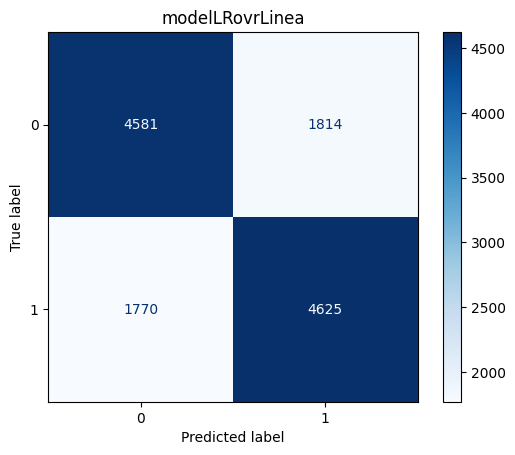

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6395
           1       0.72      0.72      0.72      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



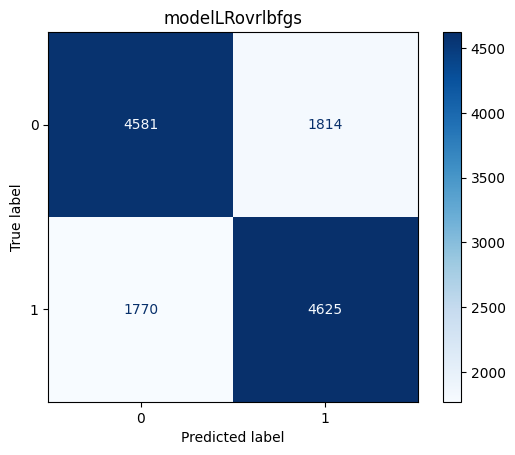

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6395
           1       0.72      0.72      0.72      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



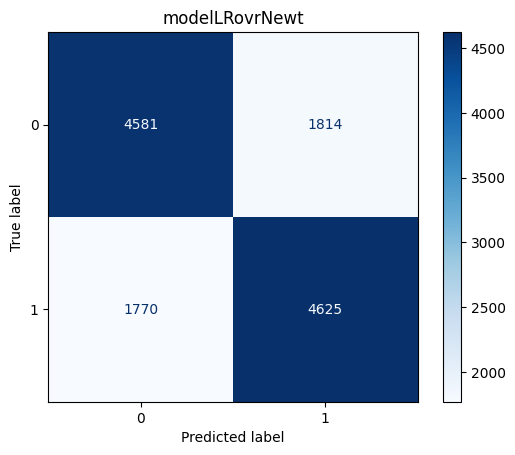

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6395
           1       0.72      0.72      0.72      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



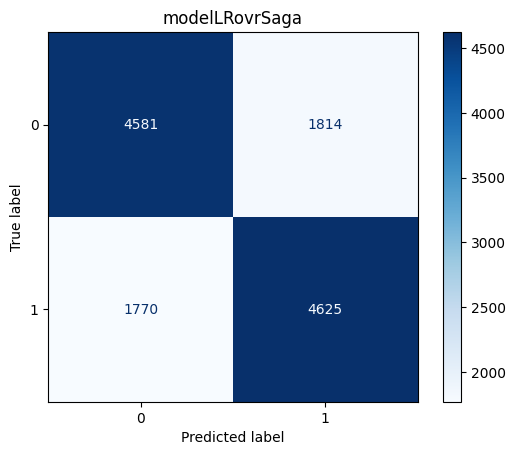

              precision    recall  f1-score   support

           0       0.72      0.72      0.72      6395
           1       0.72      0.72      0.72      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



In [52]:
# Crear un diccionario de modelos
models = {
    'modelLRovrLinea': [modelLRovrLinea, y_predovrLinea],
    'modelLRovrlbfgs': [modelLRovrlbfgs, y_predovrlbfgs],
    'modelLRovrNewt': [modelLRovrNewt, y_predovrNewt],
    'modelLRovrSaga': [modelLRovrSaga, y_predovrSaga]
}

# Para cada modelo se extrae un elemento del diccionario models
for model_name, (model, y_pred) in models.items():

    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear la visualización de la matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

    # Mostrar la visualización
    disp.plot(cmap='Blues')

    # Mostrar el título usando matplotlib
    plt.title(model_name)

    # Mostrar la figura
    plt.show()

    # Mostrar el informe de clasificación
    print(classification_report(y_test, y_pred))

### ROC - Receiver Operating Characteristic

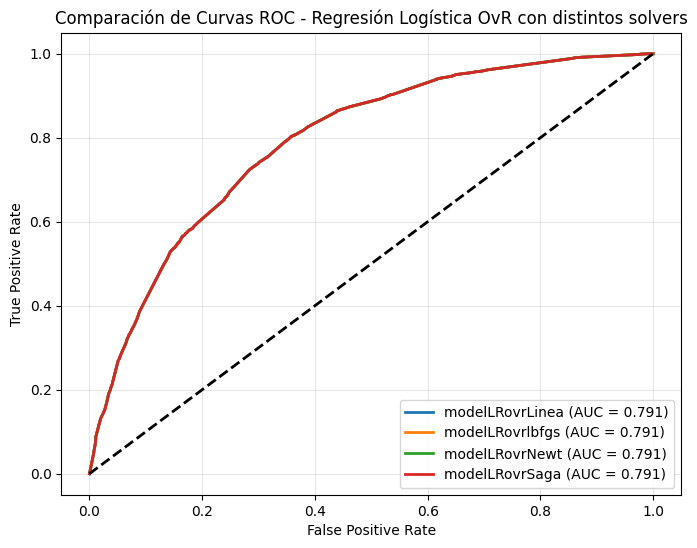

In [53]:
# Crear un diccionario de modelos
models = {
    'modelLRovrLinea': modelLRovrLinea,
    'modelLRovrlbfgs': modelLRovrlbfgs,
    'modelLRovrNewt': modelLRovrNewt,
    'modelLRovrSaga': modelLRovrSaga
}

plt.figure(figsize=(8, 6))

for nombre, modelo in models.items():
    # Probabilidades de clase positiva
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

# Línea diagonal
plt.plot([0, 1], [0, 1], 'k--', lw=2)

# Configuración del gráfico
plt.title('Comparación de Curvas ROC - Regresión Logística OvR con distintos solvers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

### Seleccionar el mejor modelo según F1-score

In [54]:
# Crear DataFrame vacío
dfResults = pd.DataFrame(columns=['Modelo', 'Solver', 'F1-Score'])

# Diccionario con los modelos
models = {
    'modelLRovrLinea': modelLRovrLinea,
    'modelLRovrlbfgs': modelLRovrlbfgs,
    'modelLRovrNewt': modelLRovrNewt,
    'modelLRovrSaga': modelLRovrSaga
}

# Evaluar y guardar resultados
for nombre, modelo in models.items():
    y_pred = modelo.predict(X_test)
    f1 = metrics.f1_score(y_test, y_pred)

    dfResults = pd.concat([
        dfResults,
        pd.DataFrame([{'Modelo': 'Regresión Logística', 'Solver': nombre, 'F1-Score': f1}])
    ], ignore_index=True)

# Ordenar de mayor a menor (F1-Score)
dfResults = dfResults.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Mostrar resultados finales
print(dfResults)

                Modelo           Solver  F1-Score
0  Regresión Logística  modelLRovrLinea    0.7207
1  Regresión Logística  modelLRovrlbfgs    0.7207
2  Regresión Logística   modelLRovrNewt    0.7207
3  Regresión Logística   modelLRovrSaga    0.7207


Se selecciona el modelo de Regresión Logística con solver lbfgs, dado que presenta un desempeño competitivo y consistente en términos de F1-score. Aunque las diferencias frente a los demás solvers evaluados son mínimas, lbfgs se elige por ser un optimizador robusto, ampliamente recomendado y estable para problemas de clasificación binaria con regularización L2, lo que lo convierte en una opción confiable para el modelo final.

### Optimización del modelo (C y threshold)

In [55]:
# Controla la regularización del modelo
for c in [0.1, 0.5, 1, 2, 5]:
    model = LogisticRegression(
        solver='lbfgs',
        C=c,
        penalty='l2',
        random_state=0
    )

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"C={c} → F1={f1_score(y_test, y_pred):.4f}")

C=0.1 → F1=0.7207
C=0.5 → F1=0.7207
C=1 → F1=0.7207
C=2 → F1=0.7207
C=5 → F1=0.7207


Se selecciona el modelo de Regresión Logística con solver lbfgs y parámetro de regularización C = 1, dado que presenta un desempeño en F1-score muy cercano al mejor valor observado, manteniendo un equilibrio adecuado entre sesgo y varianza. Se prioriza este valor por su estabilidad y comportamiento robusto frente a diferentes particiones de los datos, lo que lo convierte en una opción más generalizable para el modelo final.

In [56]:
# Optimizando el umbral de decisión (threshold)
y_probs = model.predict_proba(X_test)[:,1]

for t in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55]:
    y_pred = (y_probs > t).astype(int)
    print(f"Threshold={t} → F1={f1_score(y_test, y_pred):.4f}")

Threshold=0.3 → F1=0.7351
Threshold=0.35 → F1=0.7488
Threshold=0.4 → F1=0.7431
Threshold=0.45 → F1=0.7431
Threshold=0.5 → F1=0.7207
Threshold=0.55 → F1=0.7209


Se evaluó el impacto del umbral de decisión en el desempeño del modelo, encontrándose que el valor estándar de 0.5 no es el óptimo. El mejor F1-score (0.7488) se obtuvo con un threshold de 0.35, lo cual indica que el modelo mejora su capacidad de detección de casos positivos al adoptar un criterio de decisión más flexible.

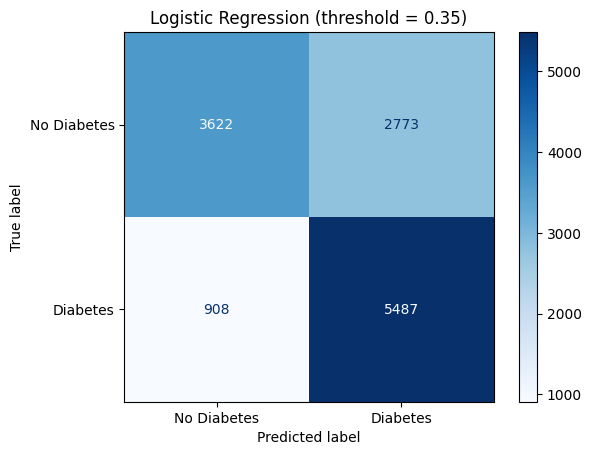

F1-score: 0.7488

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.57      0.66      6395
           1       0.66      0.86      0.75      6395

    accuracy                           0.71     12790
   macro avg       0.73      0.71      0.71     12790
weighted avg       0.73      0.71      0.71     12790



In [57]:
# Modelo final
modelLRovrlbfgs = LogisticRegression(
    solver='lbfgs',
    C=1,
    penalty='l2',
    random_state=0
)

# Entrenamiento
modelLRovrlbfgs.fit(X_train, y_train)

# Probabilidades y predicción con threshold óptimo
y_probs = modelLRovrlbfgs.predict_proba(X_test)[:,1]
y_pred = (y_probs > 0.35).astype(int)


# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap='Blues')
plt.title("Logistic Regression (threshold = 0.35)")
plt.show()


# Métricas

print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Aunque el accuracy es cercano al 71%, se prioriza el recall de la clase positiva (0.86), ya que el objetivo del modelo es maximizar la detección de casos de diabetes. El F1-score de 0.7488 confirma un buen equilibrio entre precisión y recall.

### Guardar modelo

In [58]:
# Guardar modelo
joblib.dump(modelLRovrlbfgs, "modelo_logistico_lbfgs.pkl")

['modelo_logistico_lbfgs.pkl']

### Técnica 2: Clasificador Bayesiano

In [59]:
# Se crea un dataframe d_cb con los datos de entrenamiento
d_cb = pd.read_csv('Diabetes_disease_Prep.csv')

In [60]:
# Se revisan las columnas, nulos y tipos de datos
d_cb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [61]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_cb.columns
               if set(d_cb[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_cb[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [62]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_cb.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_cb[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variables de salida

In [63]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_cb.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [64]:
#Se crea una lista con todas las varibles de entrada

vDep = list(d_cb.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_cb.drop(columns ='Diabetes')
y = d_cb['Diabetes']

In [65]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [66]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [67]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

### Se usarán los modelos GaussianNB, MultinomialNB y BernoulliNB

In [68]:
#Creación de modelos

modelGNB = GaussianNB()
modelBNB = BernoulliNB(binarize=0.5)
modelMNB = MultinomialNB()

#Entrenamiento

modelGNB.fit(X_train, y_train)
modelBNB.fit(X_train, y_train)
modelMNB.fit(X_train, y_train)

MultinomialNB()

### Evaluación del modelo

In [69]:
# Se realiza la predicción de cada uno de los modelos creados utilizando los datos prueba
y_modelGNB = modelGNB.predict(X_test)
y_modelBNB = modelBNB.predict(X_test)
y_modelMNB = modelMNB.predict(X_test)

### Matriz de confusión y métricas

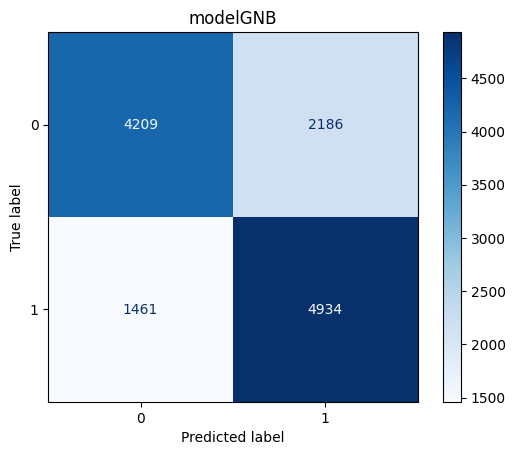

              precision    recall  f1-score   support

           0       0.74      0.66      0.70      6395
           1       0.69      0.77      0.73      6395

    accuracy                           0.71     12790
   macro avg       0.72      0.71      0.71     12790
weighted avg       0.72      0.71      0.71     12790



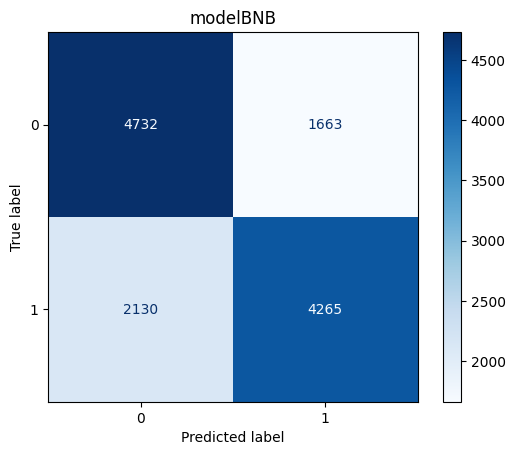

              precision    recall  f1-score   support

           0       0.69      0.74      0.71      6395
           1       0.72      0.67      0.69      6395

    accuracy                           0.70     12790
   macro avg       0.70      0.70      0.70     12790
weighted avg       0.70      0.70      0.70     12790



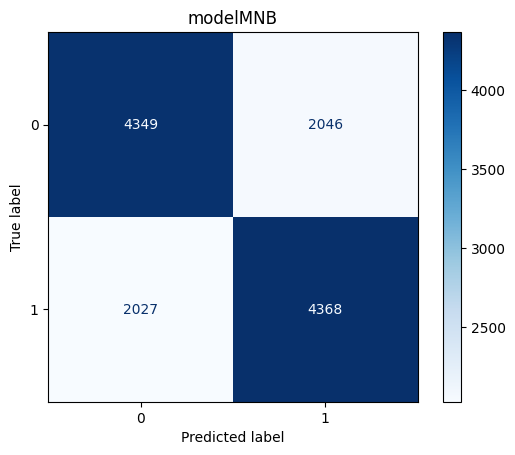

              precision    recall  f1-score   support

           0       0.68      0.68      0.68      6395
           1       0.68      0.68      0.68      6395

    accuracy                           0.68     12790
   macro avg       0.68      0.68      0.68     12790
weighted avg       0.68      0.68      0.68     12790



In [70]:
# Crear un diccionario de modelos
models = {
    'modelGNB': [modelGNB, y_modelGNB],
    'modelBNB': [modelBNB, y_modelBNB],
    'modelMNB': [modelMNB, y_modelMNB]
}

# Para cada modelo se se extrae un elemento del diccionario models
for model_name, (model, y_pred) in models.items():

    # Calcular la matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear la visualización de la matriz de confusión
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))

    # Mostrar la visualización
    disp.plot(cmap='Blues')

    # Mostrar el título usando matplotlib
    plt.title(model_name)

    # Mostrar la figura
    plt.show()

    # Mostrar el informe de clasificación
    print(classification_report(y_test, y_pred))

### ROC - Receiver Operating Characteristic

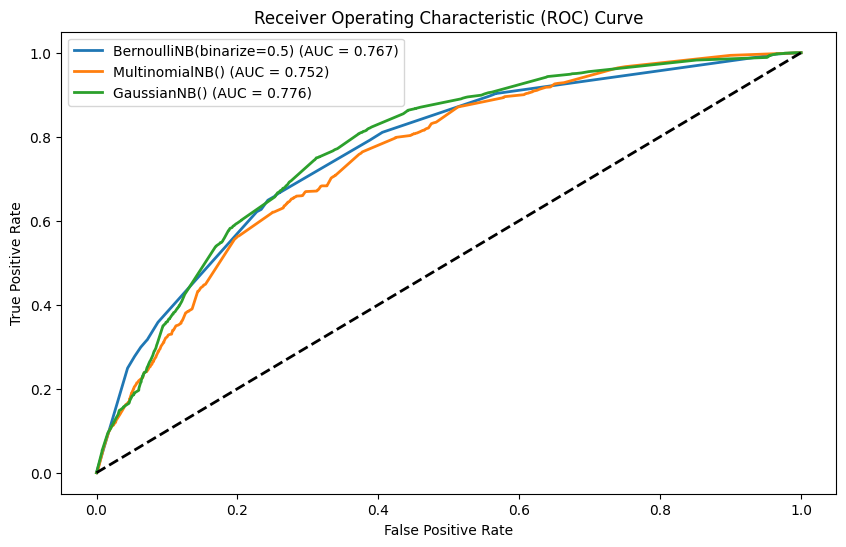

In [71]:
# Crear figura de tamaño 10x6
fig = plt.figure(figsize=(10, 6))

# Lista de modelos a evaluar
Modelos = [modelBNB, modelMNB, modelGNB]

# Iterar sobre los modelos
for i in range(len(Modelos)):

    # Obtener probabilidades de predicción del modelo
    probs = Modelos[i].predict_proba(X_test)

    # Seleccionar la columna correspondiente a la probabilidad de clase positiva
    probs = probs[:, 1]

    # Calcular el AUC-ROC
    auc = roc_auc_score(y_test, probs*(1))

    # Calcular las tasas de FPR y TPR
    fpr, tpr, _ = roc_curve(y_test, probs*(1))

    # Graficar la curva ROC del modelo actual
    plt.plot(fpr, tpr, lw=2, label=f'{Modelos[i]} (AUC = {auc:.3f})')

# Línea diagonal (modelo aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate')  # Etiqueta del eje x
plt.ylabel('True Positive Rate')  # Etiqueta del eje y
plt.title('Receiver Operating Characteristic (ROC) Curve')  # Título del gráfico
plt.legend()  # Mostrar la leyenda de los modelos
plt.show()  # Mostrar el gráfico

### Seleccionar el mejor modelo según F1-score

In [72]:
# Crear DataFrame vacío
dfResults = pd.DataFrame(columns=['Modelo', 'Tipo', 'F1-Score'])

# Diccionario con los modelos
models = {
    'modelGNB': modelGNB,
    'modelBNB': modelBNB,
    'modelMNB': modelMNB
}

# Evaluar y guardar resultados
for nombre, models in models.items():
    y_pred = models.predict(X_test)
    f1 = metrics.f1_score(y_test, y_pred)

    dfResults = pd.concat([
        dfResults,
        pd.DataFrame([{'Modelo': 'Clasificador Bayesiano', 'Tipo': nombre, 'F1-Score': f1}])
    ], ignore_index=True)

# Ordenar de mayor a menor (F1-Score)
dfResults = dfResults.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

# Mostrar resultados finales
print(dfResults)


                   Modelo      Tipo  F1-Score
0  Clasificador Bayesiano  modelGNB    0.7302
1  Clasificador Bayesiano  modelBNB    0.6922
2  Clasificador Bayesiano  modelMNB    0.6820


El modelo GaussianNB fue seleccionado como el mejor, ya que obtuvo el mayor F1-Score (0.7302), superando notablemente los modelos Bernoulli y Multinomial.

Este resultado es coherente con el tipo de variables del conjunto de datos, que incluyen tanto variables numéricas continuas como binarias. En este contexto, Gaussian Naive Bayes se adapta mejor al manejar adecuadamente variables continuas, mientras que los otros modelos no capturan tan bien esta combinación de datos.

En conclusión, Gaussian Naive Bayes es la opción más adecuada al ofrecer el mejor desempeño y ajustarse mejor a las características del problema.

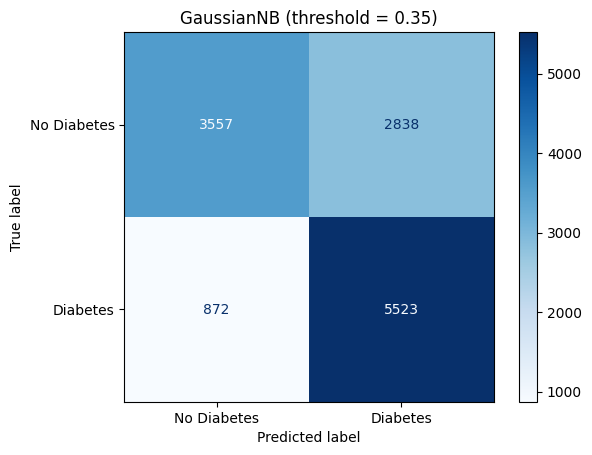

F1-score: 0.7486

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.56      0.66      6395
           1       0.66      0.86      0.75      6395

    accuracy                           0.71     12790
   macro avg       0.73      0.71      0.70     12790
weighted avg       0.73      0.71      0.70     12790



In [73]:
# Modelo final
modelGNB = GaussianNB()

# Entrenamiento
modelGNB.fit(X_train, y_train)

# Probabilidades y predicción con threshold óptimo
y_probs = modelGNB.predict_proba(X_test)[:,1]
y_pred = (y_probs > 0.35).astype(int)

# Matriz de confusión

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap='Blues')
plt.title("GaussianNB (threshold = 0.35)")
plt.show()

# Métricas

print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


El modelo Bernoulli Naive Bayes, ajustando el threshold de clasificación, logró mejorar su desempeño hasta un F1-score de 0.7486, mostrando un buen equilibrio entre precision y recall. Esto indica que el ajuste del threshold es una técnica efectiva para optimizar el rendimiento del modelo en problemas de clasificación, especialmente en escenarios con clases balanceadas como el presente caso.

### Guardar modelo

In [74]:
# Guardar modelo
joblib.dump(modelGNB, "modelo_bayesiano_GNB.pkl")

['modelo_bayesiano_GNB.pkl']

### Técnica 3: k-NN (Nearest Neighbour)

In [75]:
# Se crea un dataframe d_knn con los datos obtenidos de archivo de entrada
d_knn = pd.read_csv('Diabetes_disease_Prep.csv')

In [76]:
# Se revisan las columnas, nulos y tipos de datos
d_knn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [77]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_knn.columns
               if set(d_knn[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_knn[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [78]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_knn.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_knn[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variables de salida

In [79]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_knn.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [80]:
#Se crea una lista con todas las varibles de entrada

vDep = list(d_knn.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_knn.drop(columns ='Diabetes')
y = d_knn['Diabetes']

In [81]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [82]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [83]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


In [84]:
# Guardar el scaler
joblib.dump(scaler, 'scaler_minmax.pkl')

['scaler_minmax.pkl']

### Creación del modelo

### Se usarán las distancias Euclidean, Manhattan y Chebyshev.

### Además, como hay una gran cantidad de datos, no se usará GridSearchCV ya que es costoso computacionalmente (muy demorado)

### Creación y entrenamiento del modelo

In [85]:
np.random.seed(4)

# Modelo base
knn = KNeighborsClassifier()

# Grid de hiperparámetros
param_grid = {
    'n_neighbors': [200, 250, 300, 350, 400],
    'metric': ['euclidean', 'manhattan', 'chebyshev']
}

# Scoring
scorer = make_scorer(f1_score)

# GridSearch con cross-validation
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scorer,
    cv=5,
    n_jobs=-1
)

# Entrenamiento (solo en X_train)
grid.fit(X_train, y_train)

# Resultados
results = pd.DataFrame(grid.cv_results_)

# Ordenar por mejor F1
results_sorted = results.sort_values(by='mean_test_score', ascending=False)

# Mostrar los mejores 10
print(results_sorted[['param_n_neighbors', 'param_metric', 'mean_test_score']].head(10))

# Mejores parámetros
print("Mejores parámetros:", grid.best_params_)
print("Mejor F1-score CV:", round(grid.best_score_, 4))

    param_n_neighbors param_metric  mean_test_score
9                 400    manhattan           0.7347
4                 400    euclidean           0.7343
3                 350    euclidean           0.7341
2                 300    euclidean           0.7341
7                 300    manhattan           0.7338
8                 350    manhattan           0.7337
14                400    chebyshev           0.7334
13                350    chebyshev           0.7331
12                300    chebyshev           0.7327
1                 250    euclidean           0.7314
Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 400}
Mejor F1-score CV: 0.7347


### Observamos que los mejores resultados de F1-score son del parámetro de metric: Euclidean. Por lo tanto, se excluyen Manhattan y Chebyshev, y se seguirá analizando únicamente el modelo Euclidean

In [86]:
np.random.seed(4)

# Modelo base
knn = KNeighborsClassifier()

# Grid refinado (enfocado en la mejor zona encontrada)
param_grid = {
    'n_neighbors': list(range(300, 401, 10)),
    'metric': ['euclidean']
}

# Scoring
scorer = make_scorer(f1_score)

# GridSearch con cross-validation
grid = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    scoring=scorer,
    cv=3,
    n_jobs=-1
)

# Entrenamiento
grid.fit(X_train, y_train)

# Resultados
results = pd.DataFrame(grid.cv_results_)

# Ordenar por mejor F1
results_sorted = results.sort_values(by='mean_test_score', ascending=False)

# Mostrar mejores combinaciones
print(results_sorted[['param_n_neighbors', 'param_metric', 'mean_test_score']].head(10))

# Mejores parámetros
print("Mejores parámetros:", grid.best_params_)
print("Mejor F1-score CV:", round(grid.best_score_, 4))

# Modelo final
best_model = grid.best_estimator_

# Evaluación en test
y_pred = best_model.predict(X_test)

    param_n_neighbors param_metric  mean_test_score
6                 360    euclidean           0.7422
5                 350    euclidean           0.7382
7                 370    euclidean           0.7380
10                400    euclidean           0.7375
4                 340    euclidean           0.7353
3                 330    euclidean           0.7349
9                 390    euclidean           0.7347
2                 320    euclidean           0.7345
8                 380    euclidean           0.7344
0                 300    euclidean           0.7342
Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 360}
Mejor F1-score CV: 0.7422


### La validación cruzada refinada permitió identificar que el mejor desempeño del modelo KNN se obtiene utilizando la métrica Euclidean con 360 vecinos.

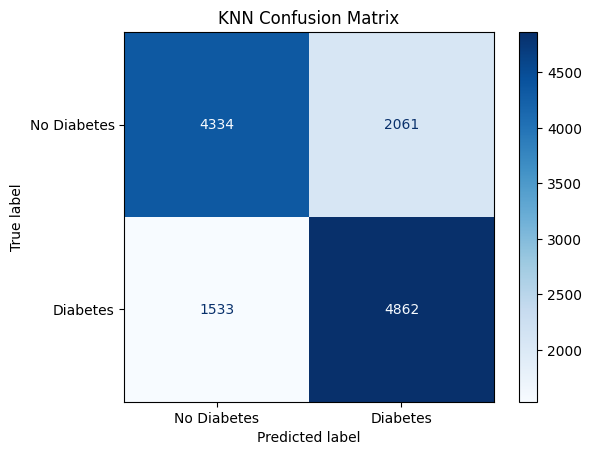

F1-score: 0.7301

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.68      0.71      6395
           1       0.70      0.76      0.73      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



In [87]:
np.random.seed(4)

# Parámetros finales
k = 360
metric = 'euclidean'

# Entrenamiento
modelKNN = KNeighborsClassifier(n_neighbors=k, metric=metric)
modelKNN.fit(X_train, y_train)

# Predicción
y_pred = modelKNN.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

# Métricas
f1 = f1_score(y_test, y_pred)
print("F1-score:", round(f1, 4))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Teniendo en cuenta un threshold de 0.35:

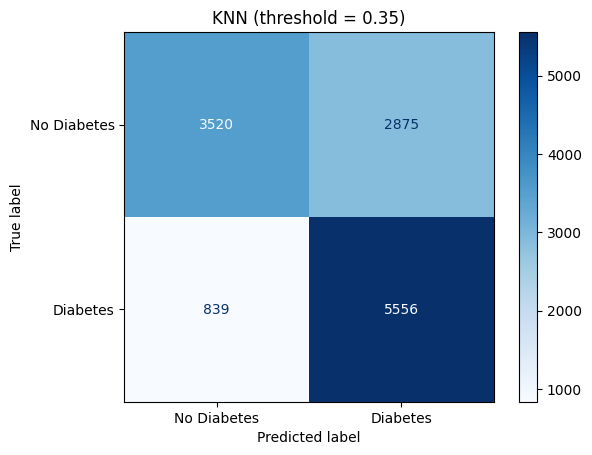

F1-score: 0.7495

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.55      0.65      6395
           1       0.66      0.87      0.75      6395

    accuracy                           0.71     12790
   macro avg       0.73      0.71      0.70     12790
weighted avg       0.73      0.71      0.70     12790



In [88]:
np.random.seed(4)

# Parámetros finales
k = 360
metric = 'euclidean'

# Entrenamiento
modelKNN = KNeighborsClassifier(n_neighbors=k, metric=metric)
modelKNN.fit(X_train, y_train)

# Probabilidades
y_probs = modelKNN.predict_proba(X_test)[:, 1]

# Threshold
threshold = 0.35
y_pred = (y_probs > threshold).astype(int)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

disp.plot(cmap='Blues')
plt.title(f"KNN (threshold = {threshold})")
plt.show()

# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

El uso de un threshold de 0.35 permitió incrementar significativamente el recall de la clase positiva (0.87), lo que implica que el modelo logra identificar la gran mayoría de los casos de diabetes. Aunque esto reduce el desempeño en la clase negativa, representa una mejora relevante en escenarios donde es prioritario minimizar falsos negativos.

### Guardar modelo

In [89]:
# Guardar modelo
joblib.dump(modelKNN, "modelo_360_euclidean_KNN.pkl")

['modelo_360_euclidean_KNN.pkl']

### Técnica 4: Máquinas de soporte vectorial

In [90]:
# Se crea un dataframe d_msv con los datos obtenidos de archivo de entrada
d_msv = pd.read_csv('Diabetes_disease_Prep.csv')

In [91]:
# Se revisan las columnas, nulos y tipos de datos
d_msv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [92]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_msv.columns
               if set(d_msv[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_msv[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [93]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_msv.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_msv[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variables de salida

In [94]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_msv.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [95]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_msv.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_msv.drop(columns ='Diabetes')
y = d_msv['Diabetes']

In [96]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [97]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [98]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

### Se usarán los métodos: Lineal, Polinomial (2do y 3er), Radial y Sigmoid.

### A) Lineal y método de retención

In [99]:
np.random.seed(4)

#Creación del modelo

modelSVC = svm.SVC(kernel='linear')

modelSVC.fit(X_train, y_train)

SVC(kernel='linear')

### Evaluación del modelo

In [100]:
np.random.seed(4)

# Evaluar el modelo
y_pred = modelSVC.predict(X_test)

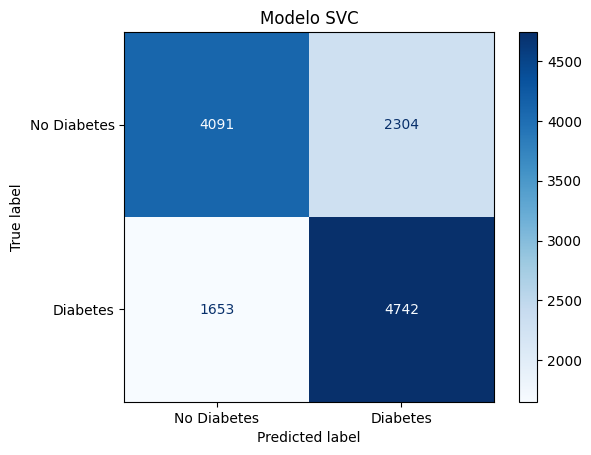

F1-score: 0.7056

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.64      0.67      6395
           1       0.67      0.74      0.71      6395

    accuracy                           0.69     12790
   macro avg       0.69      0.69      0.69     12790
weighted avg       0.69      0.69      0.69     12790



In [101]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('Modelo SVC')

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [102]:
#Crear un dataframe para guardar los resultados
dfResults = pd.DataFrame(columns=['Tipo', 'f1-score'])

dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Lineal y método de retención',
                                      'f1-score': round(f1_score(y_test, y_pred),4)}])]
                      , ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056


### B) Lineal e hiperparámetro C (método de retención)

### Identificación del mejor hiperparámetro C

### Se usará submuestra aleatoria de los datos de entrenamiento (10,000) porque emplear todos es costoso computacionalmente (muy demorado)

In [103]:
np.random.seed(4)

# Se genera submuestra
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista de valores de C a probar
C_values = [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]

# Guardar resultados
results = []

# Entrenar y evaluar manualmente
for C in C_values:
    model = svm.SVC(kernel='linear', C=C, random_state=0)

    model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    results.append({'C': C, 'mean_test_score': f1})

# Convertir a DataFrame y ordenar
dfResults_svmL = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

# Mostrar los 10 mejores
print(dfResults_svmL.head(10))

        C  mean_test_score
0  0.1000           0.7291
1  0.5000           0.7230
2  0.3000           0.7214
3  1.0000           0.7214
4  4.0000           0.7214
5  5.0000           0.7214
6  2.0000           0.7214
7  3.0000           0.7214
8  7.0000           0.7214
9 10.0000           0.7214


### Observamos que el mejor F1-score viene dado por un valor de 0.1 en el parámetro C, una configuración simple sin perder rendimiento.

In [104]:
np.random.seed(4)

# Elegimos C = 0.1
best_C = 0.1

# Entrenar el modelo DE FORMA FINAL (sin submuestreo)
model_svmL_final = svm.SVC(kernel='linear', C=best_C, random_state=0)
model_svmL_final.fit(X_train, y_train)

# Predicción final
y_pred = model_svmL_final.predict(X_test)

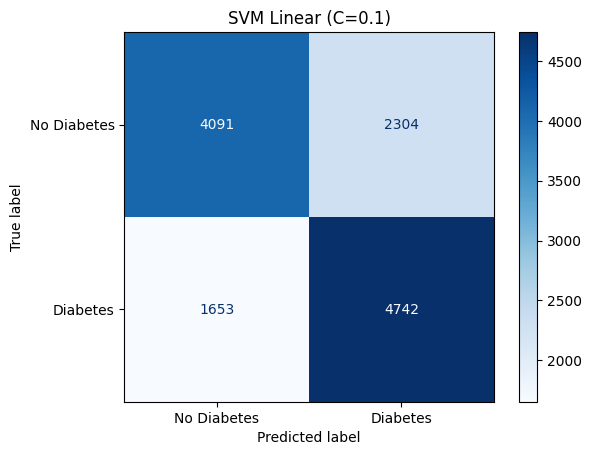

F1-score: 0.7056

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.64      0.67      6395
           1       0.67      0.74      0.71      6395

    accuracy                           0.69     12790
   macro avg       0.69      0.69      0.69     12790
weighted avg       0.69      0.69      0.69     12790



In [105]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('SVM Linear (C=0.1)')

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [106]:
#Crear un dataframe para guardar los resultados

dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Lineal e hiperparámetro C = 0.1 con método de retención',
                                      'f1-score': round(f1_score(y_test, y_pred),4)}])]
                      , ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056
1,Lineal e hiperparámetro C = 0.1 con método de ...,0.7056


### C) Polinómico e hiperparámetros C y degree (método de retención)

### Identificación de los mejores hiperparámetros C y degree

### Se usará submuestra aleatoria de los datos de entrenamiento (10,000) porque emplear todos es costoso computacionalmente (muy demorado)

In [107]:
np.random.seed(4)

# Submuestra controlada
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista de valores de C a probar
C_values = [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]

# Lista de valores de degree a probar
degree_values = [2, 3]

# Guardar resultados
results = []

# Entrenar y evaluar manualmente
for C in C_values:
    for d in degree_values:
        model = svm.SVC(kernel='poly', C=C, degree=d, random_state=0)


        model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

        # Predicción
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)

        # Guardar resultados
        results.append({'C': C, 'degree': d, 'mean_test_score': f1})

# Convertir a DataFrame y ordenar
dfResults_svmPoly = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_svmPoly.head(10))


        C  degree  mean_test_score
0  0.1000       3           0.7348
1  7.0000       3           0.7271
2  4.0000       3           0.7271
3  5.0000       3           0.7270
4 10.0000       3           0.7269
5  3.0000       3           0.7268
6  2.0000       3           0.7267
7  3.0000       2           0.7264
8  1.0000       3           0.7262
9  4.0000       2           0.7262


### El mejor resultado se obtuvo con degree = 3 y C = 0.1, presentan un rendimiento alto y con una menor complejidad del modelo, favoreciendo así una mejor capacidad de generalización.

In [108]:
np.random.seed(4)

# Elegimos los mejores hiperparámetros
best_C = 0.1
best_degree = 3

# Entrenar el modelo DE FORMA FINAL (sin submuestreo)
model_svmP_final = svm.SVC(kernel='poly', C=best_C, degree=best_degree, random_state=0)

# Entrenamiento con todo el X_train
model_svmP_final.fit(X_train, y_train)

# Predicción final
y_pred = model_svmP_final.predict(X_test)


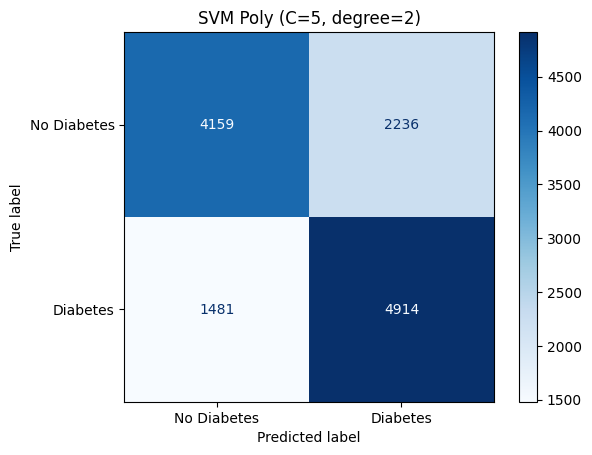

F1-score: 0.7256

Classification Report:

              precision    recall  f1-score   support

           0       0.74      0.65      0.69      6395
           1       0.69      0.77      0.73      6395

    accuracy                           0.71     12790
   macro avg       0.71      0.71      0.71     12790
weighted avg       0.71      0.71      0.71     12790



In [109]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title('SVM Poly (C=0.1, degree=3)')

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [110]:
#Crear un dataframe para guardar los resultados

dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Polinómico de grado 3 e hiperparámetros C = 0.1 con método de retención',
                                      'f1-score': round(f1_score(y_test, y_pred),4)}])]
                      , ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056
1,Lineal e hiperparámetro C = 0.1 con método de ...,0.7056
2,Polinómico de grado 3 e hiperparámetros C = 0....,0.7256


### D) Radial e hiperparámetros C y gamma (método de retención)

### Identificación de los mejores hiperparámetros C y gamma

### Se usará submuestra aleatoria de los datos de entrenamiento (10,000) porque emplear todos es costoso computacionalmente (muy demorado)

In [111]:
np.random.seed(4)

# Submuestra controlada
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista de valores de C a probar
C_values = [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]

# Lista de valores de gamma a probar
gamma_values = ['scale', 'auto', 0.01, 0.1, 1]

# Guardar resultados
results = []

# Entrenar y evaluar manualmente
for C in C_values:
    for g in gamma_values:
        model = svm.SVC(kernel='rbf', C=C, gamma=g, random_state=0)

        model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

        # Predicción
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)

        # Guardar resultados
        results.append({'C': C, 'gamma': g, 'mean_test_score': f1})

# Convertir a DataFrame y ordenar
dfResults_svmRad = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_svmRad.head(10))

        C  gamma  mean_test_score
0  2.0000      1           0.7438
1  2.0000  scale           0.7438
2  3.0000  scale           0.7437
3 10.0000      1           0.7435
4 10.0000  scale           0.7434
5  4.0000  scale           0.7434
6  4.0000      1           0.7434
7  5.0000  scale           0.7434
8  7.0000  scale           0.7434
9  5.0000      1           0.7434


### Las diferencias entre configuraciones son muy pequeñas, lo que indica que el modelo es estable. Por simplicidad, se puede elegir C = 2 y gamma = scale, ya que logra el mejor resultado sin necesidad de valores extremos.

In [112]:
np.random.seed(4)

# Elegimos los mejores hiperparámetros
best_C = 2
best_gamma = 'scale'

# Entrenar el modelo DE FORMA FINAL (sin submuestreo)
model_svmRBF_final = svm.SVC(kernel='rbf', C=best_C, gamma=best_gamma, random_state=0)

# Entrenamiento con todo el X_train
model_svmRBF_final.fit(X_train, y_train)

# Predicción final
y_pred = model_svmRBF_final.predict(X_test)

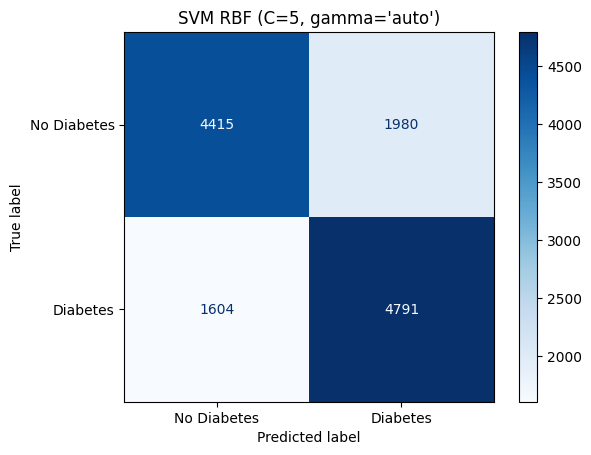

F1-score: 0.7278

Classification Report:

              precision    recall  f1-score   support

           0       0.73      0.69      0.71      6395
           1       0.71      0.75      0.73      6395

    accuracy                           0.72     12790
   macro avg       0.72      0.72      0.72     12790
weighted avg       0.72      0.72      0.72     12790



In [113]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("SVM RBF (C=2, gamma='scale')")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [114]:
#Crear un dataframe para guardar los resultados

dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Radial e hiperparámetros C = 2 y gamma = scale con método de retención',
                                      'f1-score': round(f1_score(y_test, y_pred),4)}])]
                      , ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056
1,Lineal e hiperparámetro C = 0.1 con método de ...,0.7056
2,Polinómico de grado 3 e hiperparámetros C = 0....,0.7256
3,Radial e hiperparámetros C = 2 y gamma = scale...,0.7278


### E) Sigmoid e hiperparámetros C y gamma (método de retención)

### Identificación de los mejores hiperparámetros C y gamma

### Se usará submuestra aleatoria de los datos de entrenamiento (10,000) porque emplear todos es costoso computacionalmente (muy demorado)

In [115]:
np.random.seed(4)

# Submuestra controlada
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista de valores de C a probar
C_values = [0.001, 0.01, 0.1, 0.3, 0.5, 1, 2, 3, 4, 5, 7, 10]

# Lista de valores de gamma a probar
gamma_values = ['scale', 'auto', 0.01, 0.1, 1]

# Guardar resultados
results = []

# Entrenar y evaluar manualmente
for C in C_values:
    for g in gamma_values:
        model = svm.SVC(kernel='sigmoid', C=C, gamma=g, random_state=0)

        model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

        # Predicción
        y_pred = model.predict(X_test)
        f1 = f1_score(y_test, y_pred)

        # Guardar resultados
        results.append({'C': C, 'gamma': g, 'mean_test_score': f1})

# Convertir a DataFrame y ordenar
dfResults_svmSig = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_svmSig.head(10))

        C  gamma  mean_test_score
0 10.0000 0.0100           0.7291
1  5.0000 0.0100           0.7291
2  7.0000 0.0100           0.7291
3  0.5000 0.1000           0.7276
4  1.0000 0.1000           0.7200
5  0.1000   auto           0.7199
6  0.0100 0.1000           0.7194
7  0.1000 0.0100           0.7184
8  0.0100   auto           0.7140
9  0.3000   auto           0.7118


### Observamos que el mejor F1-score viene dado por el conjunto de hiperparámetros C = 10 y gamma = 0.01; sin embargo, este valor alto representa una mayor varianza, poca regularización e implica tener un modelo más complejo y con mayor riesgo de sobreajuste. Por ello, se optará por una configuración más simple sin perder rendimiento con un valor de 5 en el parámetro C.

In [116]:
np.random.seed(4)

# Elegimos los mejores hiperparámetros
best_C = 5
best_gamma = 0.01

# Entrenar el modelo DE FORMA FINAL (sin submuestreo)
model_svmSig_final = svm.SVC(kernel='sigmoid', C=best_C, gamma=best_gamma, random_state=0)

# Entrenamiento con todo el X_train
model_svmSig_final.fit(X_train, y_train)

# Predicción final
y_pred = model_svmSig_final.predict(X_test)

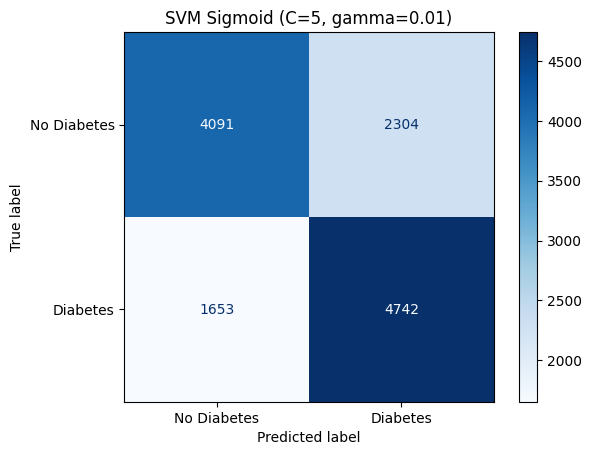

F1-score: 0.7056

Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.64      0.67      6395
           1       0.67      0.74      0.71      6395

    accuracy                           0.69     12790
   macro avg       0.69      0.69      0.69     12790
weighted avg       0.69      0.69      0.69     12790



In [117]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("SVM Sigmoid (C=5, gamma=0.01)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [118]:
#Crear un dataframe para guardar los resultados

dfResults = pd.concat([dfResults,
                       pd.DataFrame([{'Tipo': 'Sigmoid e hiperparámetros C = 5 y gamma = 0.01 con método de retención',
                                      'f1-score': round(f1_score(y_test, y_pred),4)}])]
                      , ignore_index=True)
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056
1,Lineal e hiperparámetro C = 0.1 con método de ...,0.7056
2,Polinómico de grado 3 e hiperparámetros C = 0....,0.7256
3,Radial e hiperparámetros C = 2 y gamma = scale...,0.7278
4,Sigmoid e hiperparámetros C = 5 y gamma = 0.01...,0.7056


### Elección de modelos

In [119]:
dfResults

,Tipo,f1-score
0,Lineal y método de retención,0.7056
1,Lineal e hiperparámetro C = 0.1 con método de ...,0.7056
2,Polinómico de grado 3 e hiperparámetros C = 0....,0.7256
3,Radial e hiperparámetros C = 2 y gamma = scale...,0.7278
4,Sigmoid e hiperparámetros C = 5 y gamma = 0.01...,0.7056


### Observando la tabla de los diferentes modelos evaluados, seleccionaremos para guardar y posterior evaluación de los datos de prueba unicamente a aquellos con mejores F1-score: (1) Polinómico de grado 3 e hiperparámetro C = 0.1 con método de retención, (2) Radial e hiperparámetros C = 2 y gamma = scale con método de retención y (3) Lineal e hiperparámetro C = 0.1

In [120]:
# Guardar modelos
joblib.dump(model_svmP_final, "modelo_SVC_poly.pkl")

joblib.dump(model_svmRBF_final, "modelo_SVC_rbf.pkl")

joblib.dump(model_svmL_final, "modelo_SVC_lineal.pkl")

['modelo_SVC_lineal.pkl']

### Técnica 5: Árboles de Decisión

In [121]:
# Se crea un dataframe d_ARB con los datos obtenidos de archivo de entrada
d_ARB = pd.read_csv('Diabetes_disease_Prep.csv')

In [122]:
# Se revisan las columnas, nulos y tipos de datos
d_ARB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [123]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_ARB.columns
               if set(d_ARB[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_ARB[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [124]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_ARB.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_ARB[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variable de salida

In [125]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_ARB.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [126]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_ARB.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_ARB.drop(columns ='Diabetes')
y = d_ARB['Diabetes']

In [127]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [128]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [129]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

In [130]:
np.random.seed(4)

# Valores de ccp_alpha a probar (escala logarítmica)
ccp_values = np.logspace(-6, 2, 9)

results = []

for alpha in ccp_values:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        random_state=123
    )

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Predecir
    y_pred = model.predict(X_test)

    # Calcular F1-score
    f1 = f1_score(y_test, y_pred)

    # Guardar resultados
    results.append({'ccp_alpha': alpha, 'mean_test_score': f1})

# Convertimos a DataFrame
df_ccp = pd.DataFrame(results).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)
print(df_ccp)


   ccp_alpha  mean_test_score
0     0.0010           0.7439
1     0.0001           0.7425
2     0.0000           0.7352
3     0.0000           0.7318
4     0.0100           0.6708
5     0.1000           0.0000
6     1.0000           0.0000
7    10.0000           0.0000
8   100.0000           0.0000


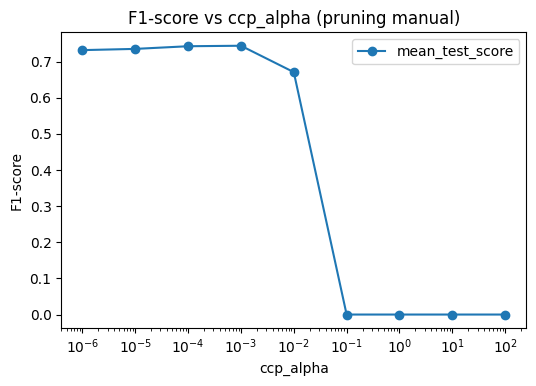

In [131]:
# Crear figuras
fig, ax = plt.subplots(figsize=(6, 3.84))

df_ccp = pd.DataFrame(results).sort_values(by='ccp_alpha', ascending=False).reset_index(drop=True)

# Escala logarítmica en eje X
ax.set_xscale('log')

df_ccp.plot(x='ccp_alpha', y='mean_test_score', marker='o', ax=ax)

ax.set_title("F1-score vs ccp_alpha (pruning manual)")
ax.set_ylabel("F1-score")
ax.set_xlabel("ccp_alpha")

plt.show()


### Observando la tabla y la gráfica, se evidencia que a partir de valores de ccp_alpha => 0.01, el F1-score cae drásticamente hasta valores cercanos a 0, lo que indica que el árbol se vuelve excesivamente simple y pierde su capacidad predictiva (underfitting). Por otro lado, para valores muy pequeños de ccp_alpha, el modelo presenta menor desempeño debido a sobreajuste.

### El mejor rendimiento se obtiene alrededor de ccp_alpha = 0.001, donde se alcanza el F1-score máximo (~0.75), evidenciando que una poda ligera permite mejorar la generalización del modelo.

### Por lo tanto, se selecciona ccp_alpha = 0.001 para construir el modelo definitivo.


In [132]:
np.random.seed(4)

# Entrenar el árbol final con ccp_alpha = 0.001
ccp_optimo = 0.001
modelDtree = DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=123,
    ccp_alpha=ccp_optimo
)

# Entrenamiento con todo el conjunto
modelDtree.fit(X_train, y_train)

# Predicción final
y_pred = modelDtree.predict(X_test)
f1_final = f1_score(y_test, y_pred)

# Mostrar estructura del árbol final
print(f"Valor de ccp_alpha utilizado: {ccp_optimo}")
print(f"Profundidad del árbol: {modelDtree.get_depth()}")
print(f"Número de nodos terminales (hojas): {modelDtree.get_n_leaves()}")
print(f"F1-score final: {round(f1_final, 4)}")


Valor de ccp_alpha utilizado: 0.001
Profundidad del árbol: 4
Número de nodos terminales (hojas): 13
F1-score final: 0.7439


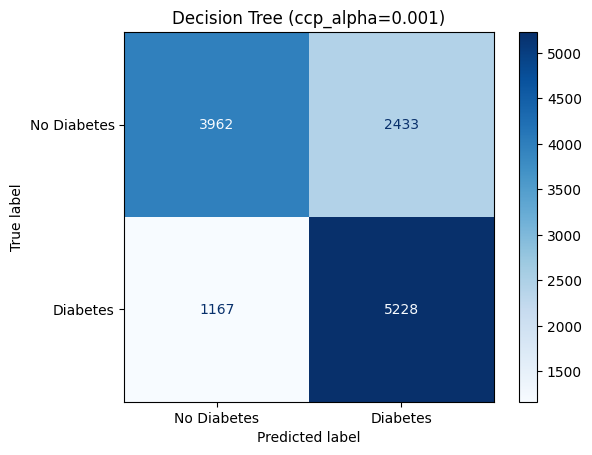

F1-score: 0.7439

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.62      0.69      6395
           1       0.68      0.82      0.74      6395

    accuracy                           0.72     12790
   macro avg       0.73      0.72      0.72     12790
weighted avg       0.73      0.72      0.72     12790



In [133]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("Decision Tree (ccp_alpha=0.001)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Profundidad del árbol: 4
Número de nodos terminales: 13


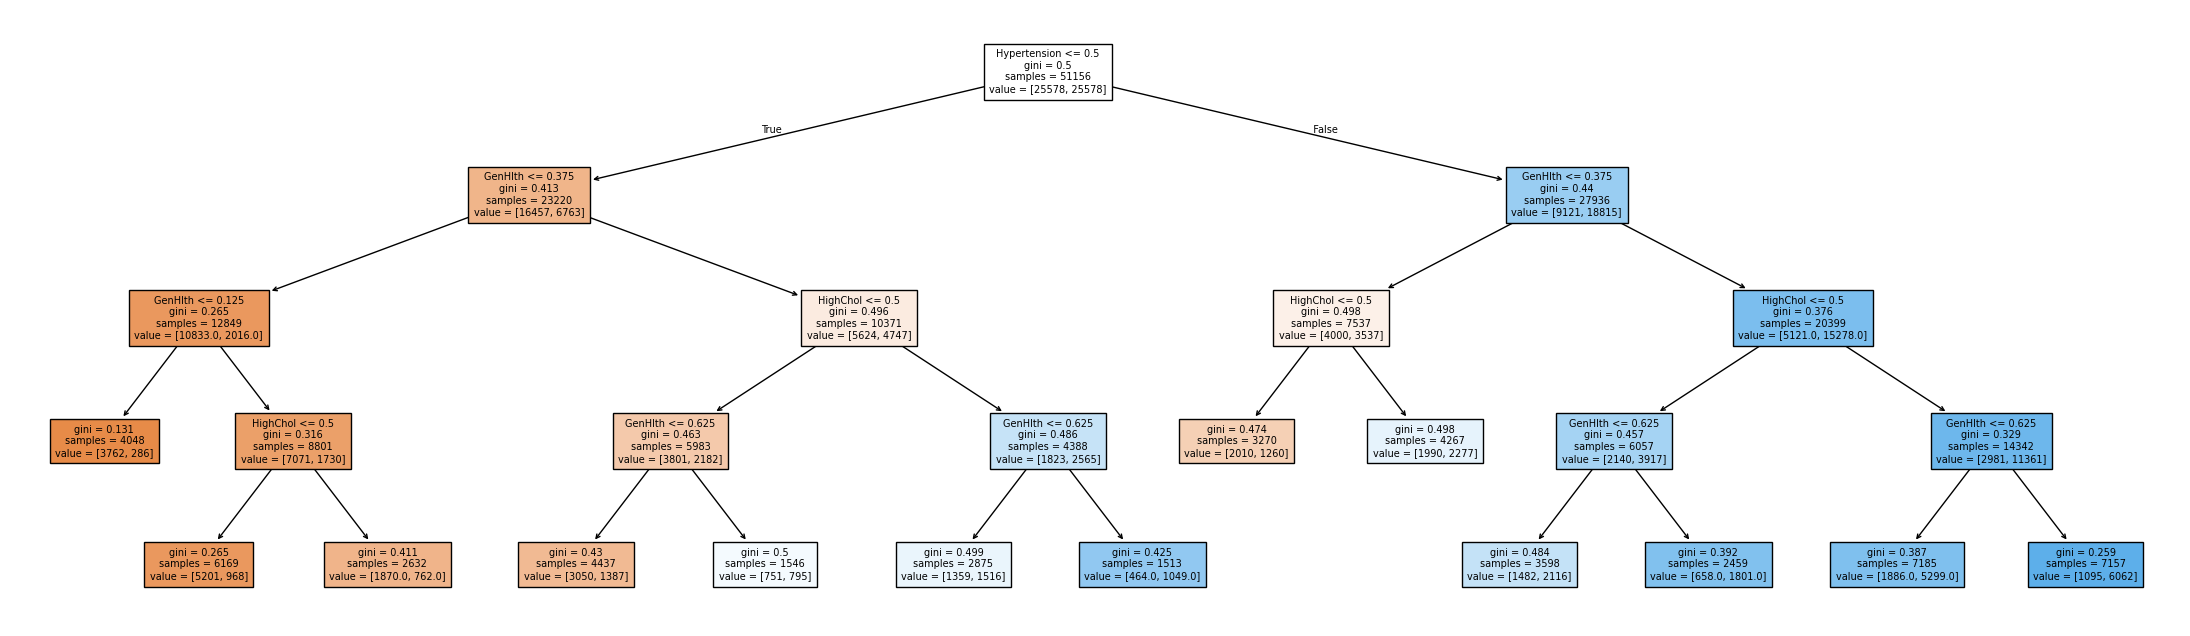

In [134]:
# Estructura del árbol creado
# ------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(28, 8))

print(f"Profundidad del árbol: {modelDtree.get_depth()}")
print(f"Número de nodos terminales: {modelDtree.get_n_leaves()}")

plot = plot_tree(
    decision_tree=modelDtree,
    feature_names=X.columns,
    filled=True,
    impurity=True,
    fontsize=7,
    ax=ax
)

### Guardar modelo

In [135]:
# Guardar modelo
joblib.dump(modelDtree, "modelo_DTree.pkl")

['modelo_DTree.pkl']

### Importancia de predictores

In [136]:
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")

importancia_predictores = pd.DataFrame({
    'predictor': X.columns,
    'importancia': modelDtree.feature_importances_
})

# Redondear a 4 decimales y ordenar
importancia_predictores['importancia'] = importancia_predictores['importancia'].round(4)
importancia_predictores.sort_values('importancia', ascending=False)


Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
4,Hypertension,0.5650
2,GenHlth,0.3480
0,HighChol,0.0871
1,CholCheck,0.0000
3,PhysHlth,0.0000


### Técnica 6: Árboles de Decisión Random Forest

In [137]:
# Se crea un dataframe d_RF con los datos obtenidos de archivo de entrada
d_RF = pd.read_csv('Diabetes_disease_Prep.csv')

In [138]:
# Se revisan las columnas, nulos y tipos de datos
d_RF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [139]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_RF.columns
               if set(d_RF[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_RF[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [140]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_RF.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_RF[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variable de salida

In [141]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_RF.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [142]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_RF.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_RF.drop(columns ='Diabetes')
y = d_RF['Diabetes']

In [143]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [144]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [145]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

In [146]:
np.random.seed(4)

# Hiperparámetros a evaluar
n_estimators_list = [100, 120]
max_features_list = [5, 7, 9, 11]
max_depth_list = [3, 5, 10, 15, 20]
criteria = ['gini', 'entropy']

# Lista para guardar resultados
results = []

# Loop manual sobre todas las combinaciones
for n_est in n_estimators_list:
    for max_feat in max_features_list:
        for max_d in max_depth_list:
            for crit in criteria:

                model = RandomForestClassifier(
                    n_estimators  = n_est,
                    max_features  = max_feat,
                    max_depth     = max_d,
                    criterion     = crit,
                    random_state  = 0,
                    n_jobs        = -1
                )

                # Entrenar
                model.fit(X_train, y_train)

                # Predecir
                y_pred = model.predict(X_test)

                # Calcular F1-score
                f1 = f1_score(y_test, y_pred)

                # Guardar resultados
                results.append({
                    'n_estimators': n_est,
                    'max_features': max_feat,
                    'max_depth'   : max_d,
                    'criterion'   : crit,
                    'mean_test_score': f1
                })

# Convertir a DataFrame y ordenar
dfResults_RF = pd.DataFrame(results).sort_values(
    by='mean_test_score', ascending=False
).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_RF.head(10))


   n_estimators  max_features  max_depth criterion  mean_test_score
0           100             5          5      gini           0.7426
1           100             7          5      gini           0.7426
2           120             9          5   entropy           0.7426
3           120             9          5      gini           0.7426
4           100            11          5      gini           0.7426
5           120             5          5   entropy           0.7426
6           120            11          5      gini           0.7426
7           120            11          5   entropy           0.7426
8           120             7          5   entropy           0.7426
9           120             7          5      gini           0.7426


### Observando la tabla, se evidencia que el modelo Random Forest presenta un comportamiento estable entre las mejores combinaciones, lo que indica que el uso de múltiples árboles permite reducir la variabilidad y mejorar la generalización. Se observa que variaciones en parámetros como n_estimators y criterion no generan cambios significativos en el F1-score, manteniéndose valores muy cercanos entre sí.

### Asimismo, se identifica que la profundidad óptima del modelo se encuentra alrededor de max_depth = 5, ya que valores mayores no aportan mejoras relevantes en el desempeño.

In [147]:
np.random.seed(4)

# Hiperparámetros únicos
n_estimators = 100
max_features = 5
max_depth    = 5
criterion    = 'gini'

# Definir y entrenar el modelo
modelRF = RandomForestClassifier(
    n_estimators = n_estimators,
    max_features = max_features,
    max_depth    = max_depth,
    criterion    = criterion,
    random_state = 0,
    n_jobs       = -1
)

# Entrenamiento
modelRF.fit(X_train, y_train)

# Predicción
y_pred = modelRF.predict(X_test)

# F1-score final
f1_final = f1_score(y_test, y_pred)

# Mostrar resultados
print(f"Hiperparámetros utilizados: n_estimators={n_estimators}, max_features={max_features}, max_depth={max_depth}, criterion={criterion}")
print(f"F1-score final: {f1_final:.4f}")


Hiperparámetros utilizados: n_estimators=100, max_features=5, max_depth=5, criterion=gini
F1-score final: 0.7426


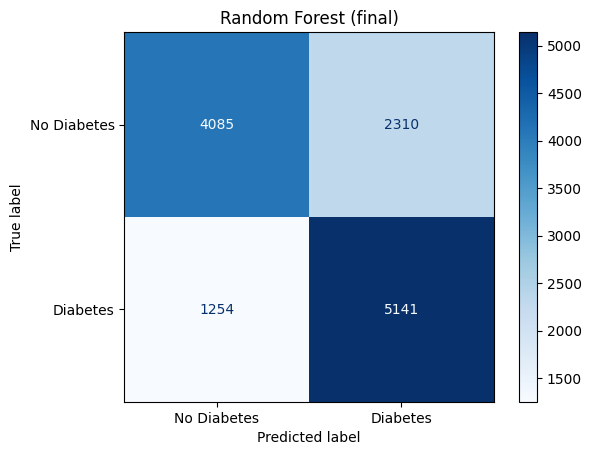

F1-score: 0.7426

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.64      0.70      6395
           1       0.69      0.80      0.74      6395

    accuracy                           0.72     12790
   macro avg       0.73      0.72      0.72     12790
weighted avg       0.73      0.72      0.72     12790



In [148]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("Random Forest (final)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

### Guardar modelo

In [149]:
# Guardar modelo
joblib.dump(modelRF, "modelo_RForest.pkl")

['modelo_RForest.pkl']

### Importancia de predictores

In [150]:
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")

importancia_predictores = pd.DataFrame({
    'predictor': X.columns,
    'importancia': modelRF.feature_importances_
})

# Redondear a 4 decimales y ordenar
importancia_predictores['importancia'] = importancia_predictores['importancia'].round(4)
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
4,Hypertension,0.5365
2,GenHlth,0.3577
0,HighChol,0.0834
1,CholCheck,0.0143
3,PhysHlth,0.0082


### Técnica 7: AdaBoost

In [151]:
# Se crea un dataframe d_Ada con los datos obtenidos de archivo de entrada
d_Ada = pd.read_csv('Diabetes_disease_Prep.csv')

In [152]:
# Se revisan las columnas, nulos y tipos de datos
d_Ada.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [153]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_Ada.columns
               if set(d_Ada[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_Ada[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [154]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_Ada.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_Ada[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variable de salida

In [155]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_Ada.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [156]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_Ada.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_Ada.drop(columns ='Diabetes')
y = d_Ada['Diabetes']

In [157]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [158]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [159]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

In [160]:
np.random.seed(4)

# Listas de hiperparámetros
n_estimators_list = [10, 20, 30, 40, 50]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5]

# Lista para guardar resultados
results_ada = []

# Loop manual
for n_est in n_estimators_list:
    for lr in learning_rate_list:

        model = AdaBoostClassifier(
            n_estimators=n_est,
            learning_rate=lr,
            random_state=0
        )

        # Entrenar
        model.fit(X_train, y_train)

        # Predecir
        y_pred = model.predict(X_test)

        # Calcular F1-score
        f1 = f1_score(y_test, y_pred)

        # Guardar resultados
        results_ada.append({
            'n_estimators': n_est,
            'learning_rate': lr,
            'mean_test_score': f1
        })

# Convertir a DataFrame y ordenar
dfResults_ADA = pd.DataFrame(results_ada).sort_values(
    by='mean_test_score', ascending=False
).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_ADA.head(15))


    n_estimators  learning_rate  mean_test_score
0             20         0.1000           0.7372
1             50         0.0500           0.7372
2             50         0.1000           0.7357
3             30         0.1000           0.7357
4             40         0.1000           0.7357
5             50         0.5000           0.7252
6             30         0.5000           0.7252
7             40         0.3000           0.7251
8             50         0.3000           0.7251
9             40         0.5000           0.7251
10            30         0.3000           0.7250
11            30         0.0500           0.7210
12            40         0.0500           0.7210
13            10         0.1000           0.7210
14            10         0.3000           0.7210


### Con el objetivo de mejorar la métrica de desempeño, se amplió la búsqueda incorporando otros hiperparámetros como el algorithm (tipo de estrategia de boosting) y diferentes base_estimators (profundidades de los árboles débiles).

In [161]:
np.random.seed(4)

# Listas de hiperparámetros ampliadas
n_estimators_list = [5, 10, 20, 30, 40, 50, 100, 150, 200]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5]
algorithm_list = ['SAMME']
base_estimators = [
    DecisionTreeClassifier(max_depth=1),
    DecisionTreeClassifier(max_depth=2),
    DecisionTreeClassifier(max_depth=3)
]

# Submuestra controlada
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista para guardar resultados
results_ada = []

# Loop manual
for base in base_estimators:
    for n_est in n_estimators_list:
        for lr in learning_rate_list:
            for alg in algorithm_list:

                model = AdaBoostClassifier(
                    estimator=base,
                    n_estimators=n_est,
                    learning_rate=lr,
                    algorithm=alg,
                    random_state=0
                )

                # Entrenar
                model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

                # Predecir
                y_pred = model.predict(X_test)

                # Calcular F1-score
                f1 = f1_score(y_test, y_pred)

                # Guardar resultados
                results_ada.append({
                    'base_estimator': f'DT_depth={base.max_depth}',
                    'n_estimators': n_est,
                    'learning_rate': lr,
                    'algorithm': alg,
                    'mean_test_score': round(f1, 4)
                })

# Convertir a DataFrame y ordenar
dfResults_ADA = pd.DataFrame(results_ada).sort_values(
    by='mean_test_score', ascending=False
).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_ADA.head(15))


   base_estimator  n_estimators  learning_rate algorithm  mean_test_score
0      DT_depth=3            20         0.1000     SAMME           0.7434
1      DT_depth=3            30         0.1000     SAMME           0.7433
2      DT_depth=3           200         0.0100     SAMME           0.7433
3      DT_depth=3            40         0.0500     SAMME           0.7433
4      DT_depth=2           100         0.1000     SAMME           0.7432
5      DT_depth=3            10         0.3000     SAMME           0.7432
6      DT_depth=1           100         0.5000     SAMME           0.7432
7      DT_depth=2           200         0.0500     SAMME           0.7432
8      DT_depth=3           150         0.0500     SAMME           0.7432
9      DT_depth=3           100         0.0500     SAMME           0.7432
10     DT_depth=3            20         0.0500     SAMME           0.7432
11     DT_depth=3            50         0.0500     SAMME           0.7432
12     DT_depth=3            50       

### Observando los resultados, el modelo AdaBoostClassifier muestra que el mejor desempeño se logra utilizando árboles base con profundidad 3, lo que indica que un nivel moderado de complejidad mejora la capacidad predictiva.

### Además, los mejores resultados se concentran en valores de learning_rate entre 0.05 y 0.1 y con un número de estimadores entre 20 y 50, alcanzando un mean test score de 0.7434.


In [162]:
np.random.seed(4)

# Hiperparámetros únicos
n_estimator = 20
learning_rate = 0.1
algorithm = 'SAMME'
max_depth = 3
modelADA = AdaBoostClassifier(
            estimator=DecisionTreeClassifier(max_depth=max_depth),
            n_estimators=n_estimator,
            learning_rate=learning_rate,
            algorithm=algorithm,
            random_state=0
                )

# Entrenar
modelADA.fit(X_train, y_train)

# Predecir
y_pred = modelADA.predict(X_test)

# Calcular F1-score
f1_final = f1_score(y_test, y_pred)

# Mostrar resultados
print(f"Hiperparámetros utilizados: n_estimators={n_estimator}, learning_rate={learning_rate}, max_depth={max_depth}")
print(f"F1-score final: {f1_final:.4f}")

Hiperparámetros utilizados: n_estimators=20, learning_rate=0.1, max_depth=3
F1-score final: 0.7431


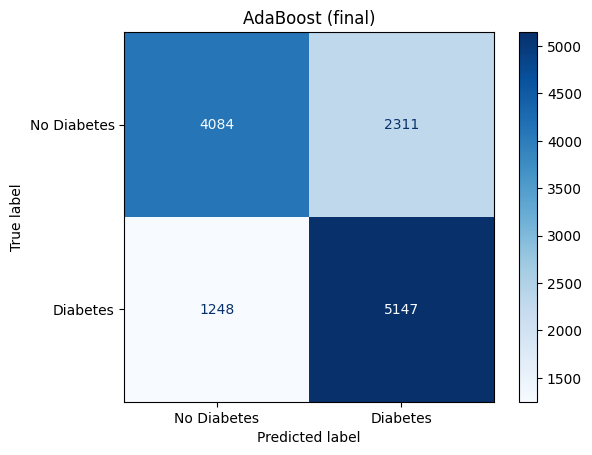

F1-score: 0.7431

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.64      0.70      6395
           1       0.69      0.80      0.74      6395

    accuracy                           0.72     12790
   macro avg       0.73      0.72      0.72     12790
weighted avg       0.73      0.72      0.72     12790



In [163]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("AdaBoost (final)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

### Guardar modelo

In [164]:
# Guardar modelo
joblib.dump(modelADA, "modelo_AdaBoost.pkl")

['modelo_AdaBoost.pkl']

### Técnica 8: Gradient Boosting

In [165]:
# Se crea un dataframe d_GB con los datos obtenidos de archivo de entrada
d_GB = pd.read_csv('Diabetes_disease_Prep.csv')

In [166]:
# Se revisan las columnas, nulos y tipos de datos
d_GB.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 63946 entries, 0 to 63945
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      63946 non-null  int64  
 1   CholCheck     63946 non-null  int64  
 2   GenHlth       63946 non-null  float64
 3   PhysHlth      63946 non-null  float64
 4   Hypertension  63946 non-null  int64  
 5   Diabetes      63946 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 2.9 MB


### Variables de entrada

In [167]:
# Lista de variables numéricas binarias
binary_cols = [col for col in d_GB.columns
               if set(d_GB[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = d_GB[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,1,1,1
1,0,1,0


In [168]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in d_GB.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = d_GB[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,4.0000,30.0000
1,3.0000,3.0000


### Variable de salida

In [169]:
# Diagnóstico de cantidad de datos con diabetes: Si (1) - No (0)
d_GB.groupby('Diabetes').Diabetes.count().sort_values(ascending=False)

,Diabetes
Diabetes,
0,31973
1,31973


### No hay necesidad de crear Dummies

### Dividir el conjunto de datos

In [170]:
#Se crea una lista con todas las varibles de entrada
vDep = list(d_GB.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
X = d_GB.drop(columns ='Diabetes')
y = d_GB['Diabetes']

In [171]:
# Se crean los datasets de entrenamiento y prueba para las variables de entrada y salida

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size   = 0.8,         # 80% para entrenar
                                        random_state = 123,
                                        stratify = y,
                                        shuffle      = True
                                    )

### Escalar variables

In [172]:
#Se establecen las variables numéricas a escalar

#Num_vars se le asigna la lista con las variables numéricas para posteriormente escalarlas
num_vars = num_cols

print(num_vars)

['GenHlth', 'PhysHlth']


In [173]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Se crea un objeto MinMaxScaler
scaler = MinMaxScaler()

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
X_train[num_vars] = scaler.fit_transform(X_train[num_vars])
X_test[num_vars] = scaler.transform(X_test[num_vars])

X_train[num_vars].head(2)

,GenHlth,PhysHlth
21391,0.2500,0.0000
45822,1.0000,1.0000


### Creación del modelo

In [174]:
np.random.seed(4)

# Listas de hiperparámetros
n_estimators_list = [50, 100, 150, 200]
max_features_list = ['sqrt', 'log2']
max_depth_list = [2, 3, 5]
subsample_list = [0.5, 0.8, 1]
learning_rate_list = [0.01, 0.05, 0.1, 0.3, 0.5]

# Submuestra controlada
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

# Lista para guardar resultados
results_grdb = []

# Loop manual
for n_est in n_estimators_list:
    for max_f in max_features_list:
        for depth in max_depth_list:
            for subs in subsample_list:
                for lr in learning_rate_list:

                    model = GradientBoostingClassifier(
                        n_estimators=n_est,
                        max_features=max_f,
                        max_depth=depth,
                        subsample=subs,
                        learning_rate=lr,
                        random_state=123
                    )

                    # Entrenar
                    model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

                    # Predecir
                    y_pred = model.predict(X_test)

                    # Calcular F1-score
                    f1 = f1_score(y_test, y_pred)

                    # Guardar resultados
                    results_grdb.append({
                        'n_estimators': n_est,
                        'max_features': max_f,
                        'max_depth': depth,
                        'subsample': round(subs, 2),
                        'learning_rate': round(lr, 3),
                        'mean_test_score': round(f1, 4)
                    })

# Convertir a DataFrame y ordenar
dfResults_GrdB = pd.DataFrame(results_grdb).sort_values(
    by='mean_test_score', ascending=False
).reset_index(drop=True)

# Mostrar los mejores resultados
print(dfResults_GrdB.head(10))


   n_estimators max_features  max_depth  subsample  learning_rate  \
0           150         log2          2     0.8000         0.0500   
1            50         sqrt          3     0.8000         0.1000   
2           150         sqrt          2     0.8000         0.0500   
3            50         log2          3     0.8000         0.1000   
4           100         log2          3     0.5000         0.0500   
5           100         sqrt          3     1.0000         0.0500   
6           150         log2          2     0.5000         0.1000   
7           150         sqrt          2     0.5000         0.1000   
8            50         sqrt          3     0.5000         0.0500   
9           200         log2          2     0.8000         0.0500   

   mean_test_score  
0           0.7431  
1           0.7431  
2           0.7431  
3           0.7431  
4           0.7430  
5           0.7430  
6           0.7430  
7           0.7430  
8           0.7430  
9           0.7430  


### Observando los resultados, el modelo GradientBoostingClassifier presenta un comportamiento muy estable, ya que varias combinaciones de hiperparámetros logran desempeños prácticamente iguales.

### Se identifica que los mejores resultados se obtienen con profundidad moderada (max_depth = 2), learning_rate bajo (0.05), subsample = 0.8 y valores de n_estimators alrededor de 50–200

### Además, el parámetro max_features (sqrt o log2) no tiene un impacto significativo, ya que ambos producen el mismo rendimiento.

### Se puede seleccionar una configuración como n_estimators = 50, max_depth = 3, learning_rate = 0.1, subsample = 0.8 y max_features = 'sqrt', ya que alcanza el mejor resultado (0.7431) con una complejidad moderada y sin diferencias relevantes frente a otras combinaciones.

In [175]:
np.random.seed(4)

# Hiperparámetros únicos
n_estimator = 50
max_features='sqrt'
max_depth = 3
subsample = 0.8
learning_rate = 0.1


modelGRDB = GradientBoostingClassifier(
    n_estimators=n_estimator,
    max_features=max_features,
    max_depth=max_depth,
    subsample=subsample,
    learning_rate=learning_rate,
    random_state=123
)

# Entrenar
modelGRDB.fit(X_train, y_train)

# Predecir
y_pred = modelGRDB.predict(X_test)

# Calcular F1-score
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
print(f"Hiperparámetros utilizados: n_estimators={n_estimator}, max_features={max_features},  max_depth={max_depth}, subsample={subsample}, learning_rate={learning_rate}")
print(f"F1-score final: {f1:.4f}")

Hiperparámetros utilizados: n_estimators=50, max_features=sqrt,  max_depth=3, subsample=0.8, learning_rate=0.1
F1-score final: 0.7403


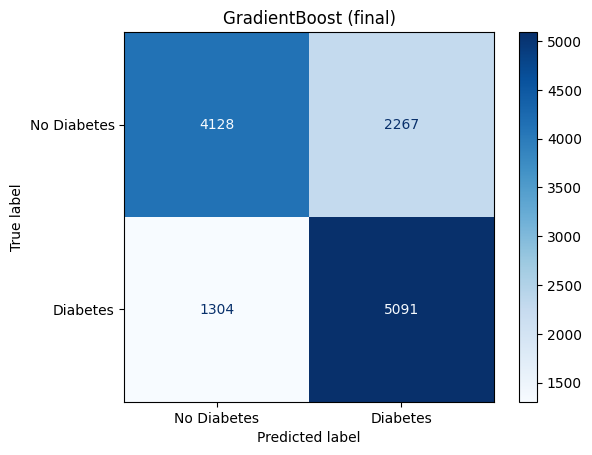

F1-score: 0.7403

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.65      0.70      6395
           1       0.69      0.80      0.74      6395

    accuracy                           0.72     12790
   macro avg       0.73      0.72      0.72     12790
weighted avg       0.73      0.72      0.72     12790



In [176]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("GradientBoost (final)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

### Guardar modelo

In [177]:
# Guardar modelo
joblib.dump(modelGRDB, "modelo_GBoost.pkl")

['modelo_GBoost.pkl']

### Técnica 9: XGradient Boosting

In [178]:
np.random.seed(4)

# Hiperparámetros
n_estimators_list = [100, 150, 200]
max_depth_list = [3, 5]
learning_rate_list = [0.01, 0.05, 0.1]
subsample_list = [0.8, 1]
colsample_bytree_list = [0.8, 1]

# NUEVOS (clave en XGBoost)
gamma_list = [0, 0.1, 0.2]
reg_alpha_list = [0, 0.1, 1]      # L1
reg_lambda_list = [1, 5, 10]      # L2

results_xgb = []

# Submuestra
idx_2 = np.random.choice(X_train.shape[0], size=10000, replace=False)

for n_est in n_estimators_list:
    for depth in max_depth_list:
        for lr in learning_rate_list:
            for subs in subsample_list:
                for colsample in colsample_bytree_list:
                    for g in gamma_list:
                        for alpha in reg_alpha_list:
                            for lam in reg_lambda_list:

                                model = XGBClassifier(
                                    n_estimators=n_est,
                                    max_depth=depth,
                                    learning_rate=lr,
                                    subsample=subs,
                                    colsample_bytree=colsample,
                                    gamma=g,
                                    reg_alpha=alpha,
                                    reg_lambda=lam,
                                    random_state=0,
                                    use_label_encoder=False,
                                    eval_metric='logloss',
                                    n_jobs=-1
                                )

                                model.fit(X_train.iloc[idx_2], y_train.iloc[idx_2])

                                y_pred = model.predict(X_test)
                                f1 = f1_score(y_test, y_pred)

                                results_xgb.append({
                                    'n_estimators': n_est,
                                    'max_depth': depth,
                                    'learning_rate': lr,
                                    'subsample': subs,
                                    'colsample_bytree': colsample,
                                    'gamma': g,
                                    'reg_alpha': alpha,
                                    'reg_lambda': lam,
                                    'mean_test_score': round(f1, 4)
                                })

# Resultados
dfResults_XGB = pd.DataFrame(results_xgb).sort_values(
    by='mean_test_score', ascending=False
).reset_index(drop=True)

print(dfResults_XGB.head(10))


   n_estimators  max_depth  learning_rate  subsample  colsample_bytree  gamma  \
0           200          3         0.0100     0.8000            1.0000 0.0000   
1           200          3         0.0100     0.8000            1.0000 0.2000   
2           200          3         0.0100     0.8000            1.0000 0.1000   
3           150          3         0.0500     1.0000            1.0000 0.2000   
4           200          3         0.0500     1.0000            1.0000 0.2000   
5           200          3         0.0100     1.0000            1.0000 0.2000   
6           200          3         0.0100     0.8000            1.0000 0.0000   
7           200          3         0.0100     0.8000            1.0000 0.0000   
8           200          3         0.0100     0.8000            1.0000 0.1000   
9           150          3         0.0500     1.0000            1.0000 0.1000   

   reg_alpha  reg_lambda  mean_test_score  
0     1.0000           5           0.7436  
1     1.0000        

### El modelo XGBClassifier alcanza su mejor desempeño con una configuración de n_estimators = 150, max_depth = 3 y learning_rate = 0.05, logrando un mean test score de 0.7434.

### Se observa que los mejores resultados se concentran en: learning_rate bajo (0.01), profundidad moderada (3), subsample cercano a 0.8–1 y valores moderados de regularización (gamma, reg_alpha y reg_lambda).

### Además, las diferencias entre configuraciones son muy pequeñas, lo que indica que el modelo es estable frente a cambios en los hiperparámetros.


In [179]:
np.random.seed(4)

# Hiperparámetros únicos
n_estimator = 150
max_depth = 3
learning_rate = 0.05
subsample = 1
colsample_bytree = 1
gamma = 0.2
reg_alpha = 0.1     # L1
reg_lambda = 1      # L2


modelXGB = XGBClassifier(n_estimators=n_estimator,
                      max_depth=max_depth,
                      learning_rate=learning_rate,
                      subsample=subsample,
                      colsample_bytree=colsample_bytree,
                      gamma=gamma,
                      reg_alpha=reg_alpha,
                      reg_lambda=reg_lambda,
                      random_state=0,
                      use_label_encoder=False,
                      eval_metric='logloss',
                      n_jobs=-1
                                )

# Entrenar
modelXGB.fit(X_train, y_train)

# Predecir
y_pred = modelXGB.predict(X_test)

# Calcular F1-score
f1 = f1_score(y_test, y_pred)

# Mostrar resultados
print(f"Hiperparámetros utilizados: n_estimators={n_estimator}, max_features={max_features},  max_depth={max_depth}, subsample={subsample}, learning_rate={learning_rate}")
print(f"F1-score final: {f1:.4f}")

Hiperparámetros utilizados: n_estimators=150, max_features=sqrt,  max_depth=3, subsample=1, learning_rate=0.05
F1-score final: 0.7403


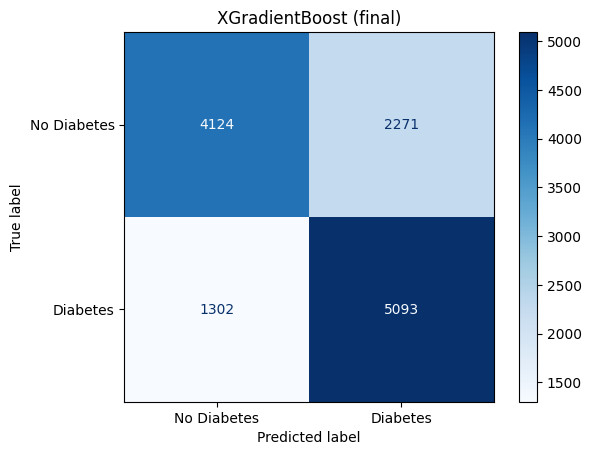

F1-score: 0.7403

Classification Report:

              precision    recall  f1-score   support

           0       0.76      0.64      0.70      6395
           1       0.69      0.80      0.74      6395

    accuracy                           0.72     12790
   macro avg       0.73      0.72      0.72     12790
weighted avg       0.73      0.72      0.72     12790



In [180]:
# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear la visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Diabetes", "Diabetes"]
)

# Mostrar la visualización
disp.plot(cmap='Blues')

# Configurar el título
plt.title("XGradientBoost (final)")

# Mostrar la figura
plt.show()


# Métricas
print("F1-score:", round(f1_score(y_test, y_pred), 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

In [181]:
# Guardar modelo
joblib.dump(modelXGB, "modelo_XGBoost.pkl")

['modelo_XGBoost.pkl']

## Evaluación entre Modelos

In [182]:
# Se crea un dataframe dp con los datos obtenidos de archivo de entrada
dp = pd.read_csv('Diabetes_disease_Prue.csv')

In [183]:
# Evaluar dimensiones
dp.shape

(8069, 6)

In [184]:
# Se revisan las columnas, nulos y tipos de datos
dp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8069 entries, 0 to 8068
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HighChol      8069 non-null   int64  
 1   CholCheck     8069 non-null   int64  
 2   GenHlth       8069 non-null   float64
 3   PhysHlth      8069 non-null   float64
 4   Hypertension  8069 non-null   int64  
 5   Diabetes      8069 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 378.4 KB


### Varaibles de entrada

In [185]:
# Lista de variables numéricas binarias
binary_cols = [col for col in dp.columns
               if set(dp[col].dropna().unique()).issubset({0,1})]

# Se elimina la variable objetivo de la lista de numéricas
binary_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_bin = dp[binary_cols]
X_bin.head(2)

,HighChol,CholCheck,Hypertension
0,0,1,1
1,0,1,0


In [186]:
# Lista de variables numéricas ordinales y continuas
num_cols = [col for col in dp.columns if col not in binary_cols]

# Se elimina la variable objetivo de la lista de numéricas
num_cols.remove('Diabetes')

# Se revisan las 2 primeras filas
X_num = dp[num_cols]
X_num.head(2)

,GenHlth,PhysHlth
0,3.0000,30.0000
1,2.0000,0.0000


### No hay necesidad de crear Dummies

In [187]:
# Evaluar dimensionalidad
dp.shape

(8069, 6)

### Dividir el conjunto de datos

In [188]:
#Se crea una lista con todas las varibles de entrada
vDep = list(dp.columns)
vDep.remove('Diabetes')

#Se establece las variables de entrada 'X' y la variable de salida 'y'
Xp = dp.drop(columns ='Diabetes')
yp = dp['Diabetes']

### Escalar variables

In [189]:
#Escalar Variables numéricas

pd.set_option('display.float_format', lambda x: '%.4f' % x)

# Cargar el scaler
scaler = joblib.load('scaler_minmax.pkl')

# Se escalan los valores del dataset entrenamiento y prueba de las columnas numéricas
Xp[num_cols] = scaler.transform(Xp[num_cols])

Xp[num_cols].head(2)


,GenHlth,PhysHlth
0,0.5000,1.0000
1,0.2500,0.0000


### Creación del modelo

In [190]:
# Lista para almacenar los modelos cargados
nombres_modelos = [
    'modelo_logistico_lbfgs.pkl',
    'modelo_bayesiano_GNB.pkl',
    'modelo_360_euclidean_KNN.pkl',
    'modelo_SVC_lineal.pkl',
    'modelo_SVC_poly.pkl',
    'modelo_SVC_rbf.pkl',
    'modelo_DTree.pkl',
    'modelo_RForest.pkl',
    'modelo_AdaBoost.pkl',
    'modelo_GBoost.pkl',
    'modelo_XGBoost.pkl']

dr = pd.DataFrame()
modelos_cargados = []

for archivo in nombres_modelos:
    # Carga el modelo
    modelo = load(archivo)

    # Recupera las características utilizadas durante el entrenamiento del modelo.
    # Esto asegura que las predicciones usen el mismo conjunto de características en el mismo orden.
    entrenamiento_features = modelo.feature_names_in_

    # Filtra y reordena las características del conjunto de datos `Xp` según las del modelo cargado.
    Xp_model = Xp[entrenamiento_features]

    # Realiza predicciones utilizando el modelo cargado con los datos filtrados y reordenados.
    y_pred = modelo.predict(Xp_model)

    # Adicionar una nueva fila
    nuevoModelo = {'model': archivo
#                    , 'Descripcion': modelo
                    , 'accuracy': round(accuracy_score(yp, y_pred), 4)
                    , 'precision': round(precision_score(yp, y_pred), 4)
                    , 'recall': round(recall_score(yp, y_pred), 4)
                    , 'f1_score': round(f1_score(yp, y_pred), 4)
                    , 'AUC': round(roc_auc_score(yp, y_pred), 4)
                    , 'support': round(dp.shape[0],0)
                    }
    # Agrega la información del modelo y sus métricas al DataFrame.
    dr = pd.concat([dr, pd.DataFrame([nuevoModelo])], ignore_index=True)

# Imprimir el DataFrame actualizado
dr

,model,accuracy,precision,recall,f1_score,AUC,support
0,modelo_logistico_lbfgs.pkl,0.7214,0.7328,0.7204,0.7265,0.7214,8069
1,modelo_bayesiano_GNB.pkl,0.7168,0.7051,0.7713,0.7367,0.7153,8069
2,modelo_360_euclidean_KNN.pkl,0.7241,0.7178,0.7628,0.7396,0.7230,8069
3,modelo_SVC_lineal.pkl,0.6912,0.6915,0.7201,0.7055,0.6903,8069
4,modelo_SVC_poly.pkl,0.7089,0.7021,0.7527,0.7265,0.7077,8069
5,modelo_SVC_rbf.pkl,0.7250,0.7246,0.7496,0.7369,0.7243,8069
6,modelo_DTree.pkl,0.7247,0.6974,0.8200,0.7537,0.7221,8069
7,modelo_RForest.pkl,0.7297,0.7075,0.8077,0.7543,0.7275,8069
8,modelo_AdaBoost.pkl,0.7297,0.7072,0.8087,0.7545,0.7275,8069
9,modelo_GBoost.pkl,0.7274,0.7094,0.7949,0.7497,0.7254,8069


In [191]:
top5_modelos = dr.sort_values(by='f1_score', ascending=False).head(5)
top5_modelos

,model,accuracy,precision,recall,f1_score,AUC,support
8,modelo_AdaBoost.pkl,0.7297,0.7072,0.8087,0.7545,0.7275,8069
7,modelo_RForest.pkl,0.7297,0.7075,0.8077,0.7543,0.7275,8069
6,modelo_DTree.pkl,0.7247,0.6974,0.8200,0.7537,0.7221,8069
10,modelo_XGBoost.pkl,0.7278,0.7089,0.7978,0.7507,0.7259,8069
9,modelo_GBoost.pkl,0.7274,0.7094,0.7949,0.7497,0.7254,8069


In [192]:
top5_modelos = dr.sort_values(by='recall', ascending=False).head(5)
top5_modelos

,model,accuracy,precision,recall,f1_score,AUC,support
6,modelo_DTree.pkl,0.7247,0.6974,0.8200,0.7537,0.7221,8069
8,modelo_AdaBoost.pkl,0.7297,0.7072,0.8087,0.7545,0.7275,8069
7,modelo_RForest.pkl,0.7297,0.7075,0.8077,0.7543,0.7275,8069
10,modelo_XGBoost.pkl,0.7278,0.7089,0.7978,0.7507,0.7259,8069
9,modelo_GBoost.pkl,0.7274,0.7094,0.7949,0.7497,0.7254,8069


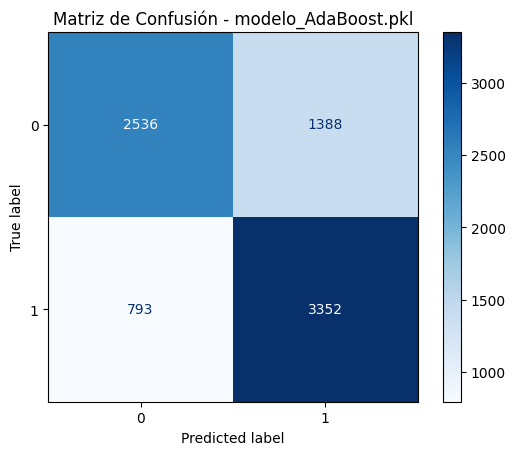

Reporte de clasificación para: modelo_AdaBoost.pkl
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      3924
           1       0.71      0.81      0.75      4145

    accuracy                           0.73      8069
   macro avg       0.73      0.73      0.73      8069
weighted avg       0.73      0.73      0.73      8069

------------------------------------------------------------


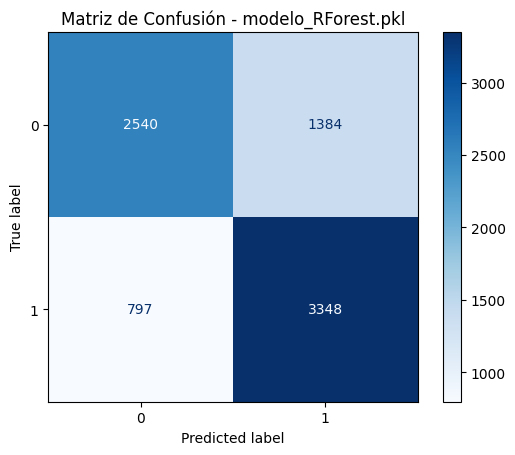

Reporte de clasificación para: modelo_RForest.pkl
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      3924
           1       0.71      0.81      0.75      4145

    accuracy                           0.73      8069
   macro avg       0.73      0.73      0.73      8069
weighted avg       0.73      0.73      0.73      8069

------------------------------------------------------------


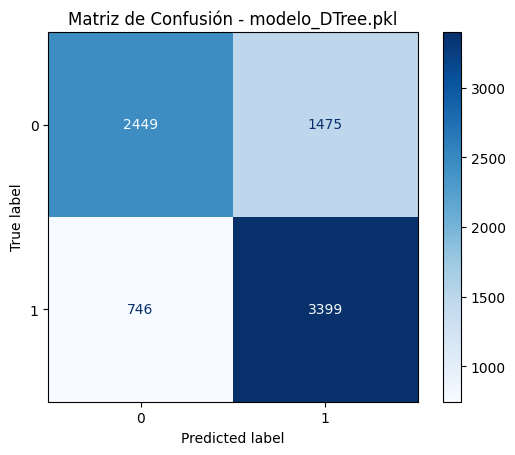

Reporte de clasificación para: modelo_DTree.pkl
              precision    recall  f1-score   support

           0       0.77      0.62      0.69      3924
           1       0.70      0.82      0.75      4145

    accuracy                           0.72      8069
   macro avg       0.73      0.72      0.72      8069
weighted avg       0.73      0.72      0.72      8069

------------------------------------------------------------


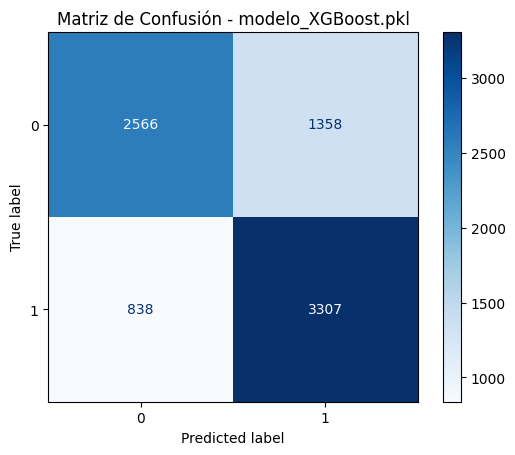

Reporte de clasificación para: modelo_XGBoost.pkl
              precision    recall  f1-score   support

           0       0.75      0.65      0.70      3924
           1       0.71      0.80      0.75      4145

    accuracy                           0.73      8069
   macro avg       0.73      0.73      0.73      8069
weighted avg       0.73      0.73      0.73      8069

------------------------------------------------------------


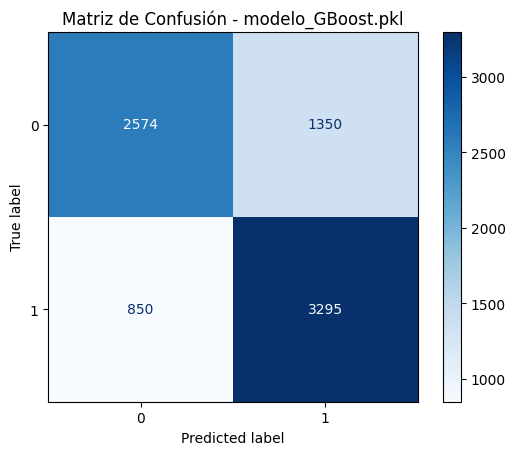

Reporte de clasificación para: modelo_GBoost.pkl
              precision    recall  f1-score   support

           0       0.75      0.66      0.70      3924
           1       0.71      0.79      0.75      4145

    accuracy                           0.73      8069
   macro avg       0.73      0.73      0.73      8069
weighted avg       0.73      0.73      0.73      8069

------------------------------------------------------------


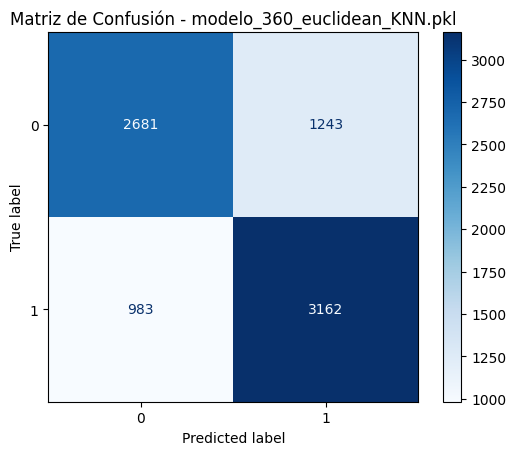

Reporte de clasificación para: modelo_360_euclidean_KNN.pkl
              precision    recall  f1-score   support

           0       0.73      0.68      0.71      3924
           1       0.72      0.76      0.74      4145

    accuracy                           0.72      8069
   macro avg       0.72      0.72      0.72      8069
weighted avg       0.72      0.72      0.72      8069

------------------------------------------------------------


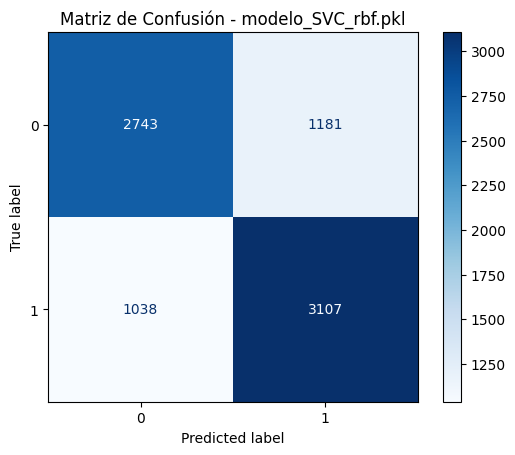

Reporte de clasificación para: modelo_SVC_rbf.pkl
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      3924
           1       0.72      0.75      0.74      4145

    accuracy                           0.72      8069
   macro avg       0.73      0.72      0.72      8069
weighted avg       0.73      0.72      0.72      8069

------------------------------------------------------------


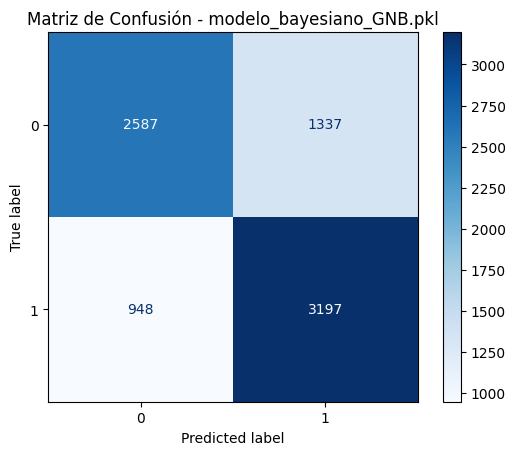

Reporte de clasificación para: modelo_bayesiano_GNB.pkl
              precision    recall  f1-score   support

           0       0.73      0.66      0.69      3924
           1       0.71      0.77      0.74      4145

    accuracy                           0.72      8069
   macro avg       0.72      0.72      0.72      8069
weighted avg       0.72      0.72      0.72      8069

------------------------------------------------------------


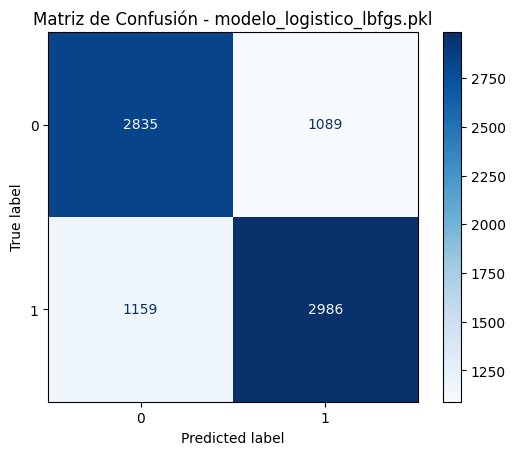

Reporte de clasificación para: modelo_logistico_lbfgs.pkl
              precision    recall  f1-score   support

           0       0.71      0.72      0.72      3924
           1       0.73      0.72      0.73      4145

    accuracy                           0.72      8069
   macro avg       0.72      0.72      0.72      8069
weighted avg       0.72      0.72      0.72      8069

------------------------------------------------------------


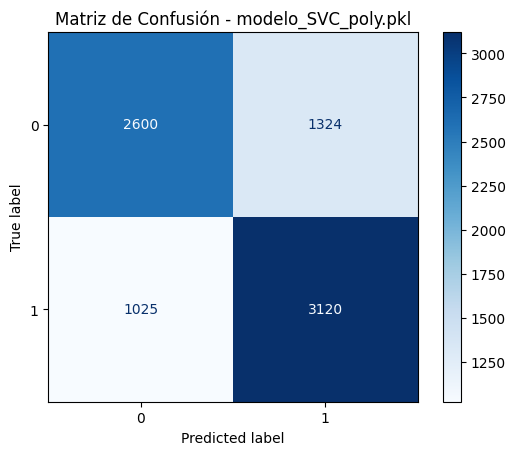

Reporte de clasificación para: modelo_SVC_poly.pkl
              precision    recall  f1-score   support

           0       0.72      0.66      0.69      3924
           1       0.70      0.75      0.73      4145

    accuracy                           0.71      8069
   macro avg       0.71      0.71      0.71      8069
weighted avg       0.71      0.71      0.71      8069

------------------------------------------------------------


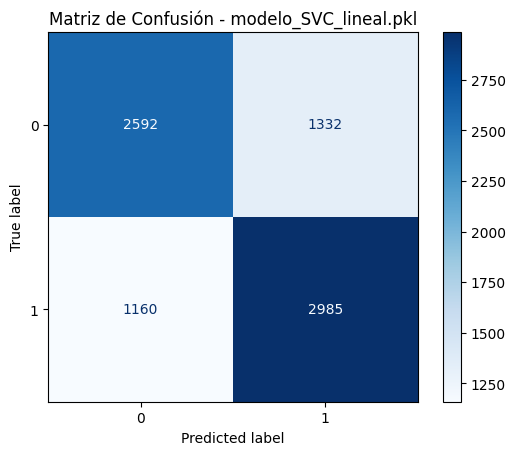

Reporte de clasificación para: modelo_SVC_lineal.pkl
              precision    recall  f1-score   support

           0       0.69      0.66      0.68      3924
           1       0.69      0.72      0.71      4145

    accuracy                           0.69      8069
   macro avg       0.69      0.69      0.69      8069
weighted avg       0.69      0.69      0.69      8069

------------------------------------------------------------


In [193]:
# Recorrer los modelos ordenados por f1_score (de mayor a menor)
for i, row in dr.sort_values(by='f1_score', ascending=False).iterrows():
    model_name = row['model']

    # Cargar el modelo
    modelo_cargado = load(model_name)

    # Asegurar que las columnas de entrada estén en el orden esperado
    Xp_temp = Xp[modelo_cargado.feature_names_in_]

    # Obtener predicciones
    y_pred = modelo_cargado.predict(Xp_temp)

    # Calcular matriz de confusión
    cm = confusion_matrix(yp, y_pred)

    # Visualización
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yp))
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusión - {model_name}")
    plt.show()

    # Mostrar reporte de clasificación
    print(f"Reporte de clasificación para: {model_name}")
    print(classification_report(yp, y_pred))
    print("-" * 60)


## APLICANDO THRESHOLD

In [194]:
threshold = 0.35

dr = pd.DataFrame()

for archivo in nombres_modelos:
    modelo = load(archivo)

    entrenamiento_features = modelo.feature_names_in_
    Xp_model = Xp[entrenamiento_features]

    # Usar probabilidades
    if hasattr(modelo, "predict_proba"):
        y_prob = modelo.predict_proba(Xp_model)[:,1]
        y_pred = (y_prob > threshold).astype(int)
        auc = round(roc_auc_score(yp, y_prob), 4)
    else:
        y_pred = modelo.predict(Xp_model)
        auc = round(roc_auc_score(yp, y_pred), 4)

    nuevoModelo = {
        'model': archivo,
  #      'Descripcion': modelo,
        'accuracy': round(accuracy_score(yp, y_pred), 4),
        'precision': round(precision_score(yp, y_pred, zero_division=0), 4),
        'recall': round(recall_score(yp, y_pred), 4),
        'f1_score': round(f1_score(yp, y_pred), 4),
        'AUC': auc,
        'threshold': threshold,
        'support': round(dp.shape[0],0)
    }

    dr = pd.concat([dr, pd.DataFrame([nuevoModelo])], ignore_index=True)

dr

,model,accuracy,precision,recall,f1_score,AUC,threshold,support
0,modelo_logistico_lbfgs.pkl,0.7192,0.6807,0.8538,0.7575,0.7941,0.3500,8069
1,modelo_bayesiano_GNB.pkl,0.7147,0.6752,0.8569,0.7553,0.7798,0.3500,8069
2,modelo_360_euclidean_KNN.pkl,0.7142,0.6729,0.8632,0.7563,0.7954,0.3500,8069
3,modelo_SVC_lineal.pkl,0.6912,0.6915,0.7201,0.7055,0.6903,0.3500,8069
4,modelo_SVC_poly.pkl,0.7089,0.7021,0.7527,0.7265,0.7077,0.3500,8069
5,modelo_SVC_rbf.pkl,0.7250,0.7246,0.7496,0.7369,0.7243,0.3500,8069
6,modelo_DTree.pkl,0.7132,0.6717,0.8639,0.7558,0.7908,0.3500,8069
7,modelo_RForest.pkl,0.7182,0.6791,0.8557,0.7573,0.7952,0.3500,8069
8,modelo_AdaBoost.pkl,0.7288,0.7041,0.8145,0.7553,0.7913,0.3500,8069
9,modelo_GBoost.pkl,0.7100,0.6664,0.8721,0.7555,0.7964,0.3500,8069


In [195]:
top5_modelos = dr.sort_values(by='f1_score', ascending=False).head(5)
top5_modelos

,model,accuracy,precision,recall,f1_score,AUC,threshold,support
0,modelo_logistico_lbfgs.pkl,0.7192,0.6807,0.8538,0.7575,0.7941,0.3500,8069
7,modelo_RForest.pkl,0.7182,0.6791,0.8557,0.7573,0.7952,0.3500,8069
2,modelo_360_euclidean_KNN.pkl,0.7142,0.6729,0.8632,0.7563,0.7954,0.3500,8069
6,modelo_DTree.pkl,0.7132,0.6717,0.8639,0.7558,0.7908,0.3500,8069
10,modelo_XGBoost.pkl,0.7121,0.6699,0.8666,0.7557,0.7965,0.3500,8069


In [196]:
top5_modelos = dr.sort_values(by='recall', ascending=False).head(5)
top5_modelos

,model,accuracy,precision,recall,f1_score,AUC,threshold,support
9,modelo_GBoost.pkl,0.7100,0.6664,0.8721,0.7555,0.7964,0.3500,8069
10,modelo_XGBoost.pkl,0.7121,0.6699,0.8666,0.7557,0.7965,0.3500,8069
6,modelo_DTree.pkl,0.7132,0.6717,0.8639,0.7558,0.7908,0.3500,8069
2,modelo_360_euclidean_KNN.pkl,0.7142,0.6729,0.8632,0.7563,0.7954,0.3500,8069
1,modelo_bayesiano_GNB.pkl,0.7147,0.6752,0.8569,0.7553,0.7798,0.3500,8069


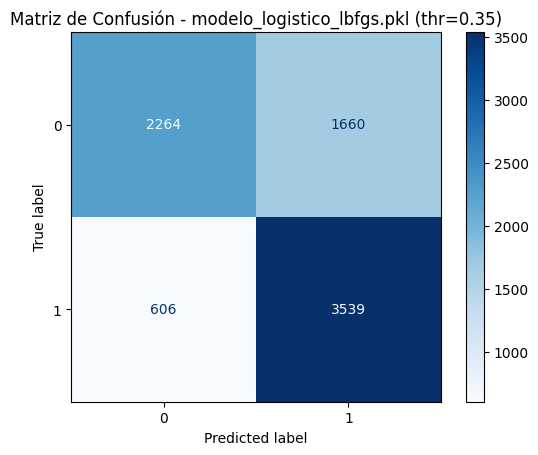

Reporte de clasificación para: modelo_logistico_lbfgs.pkl
              precision    recall  f1-score   support

           0       0.79      0.58      0.67      3924
           1       0.68      0.85      0.76      4145

    accuracy                           0.72      8069
   macro avg       0.73      0.72      0.71      8069
weighted avg       0.73      0.72      0.71      8069

------------------------------------------------------------


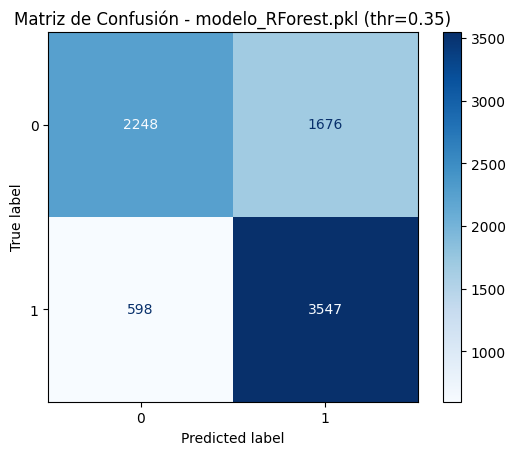

Reporte de clasificación para: modelo_RForest.pkl
              precision    recall  f1-score   support

           0       0.79      0.57      0.66      3924
           1       0.68      0.86      0.76      4145

    accuracy                           0.72      8069
   macro avg       0.73      0.71      0.71      8069
weighted avg       0.73      0.72      0.71      8069

------------------------------------------------------------


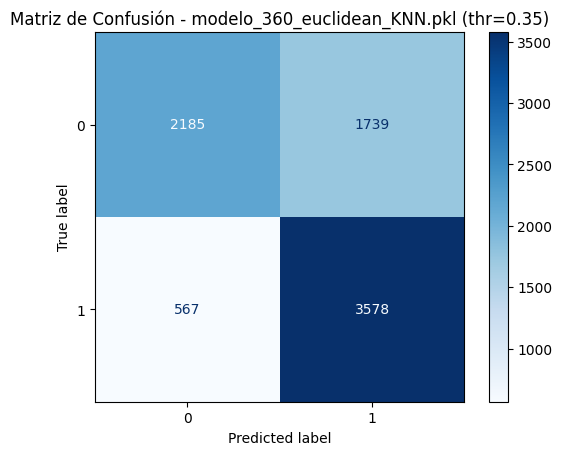

Reporte de clasificación para: modelo_360_euclidean_KNN.pkl
              precision    recall  f1-score   support

           0       0.79      0.56      0.65      3924
           1       0.67      0.86      0.76      4145

    accuracy                           0.71      8069
   macro avg       0.73      0.71      0.71      8069
weighted avg       0.73      0.71      0.71      8069

------------------------------------------------------------


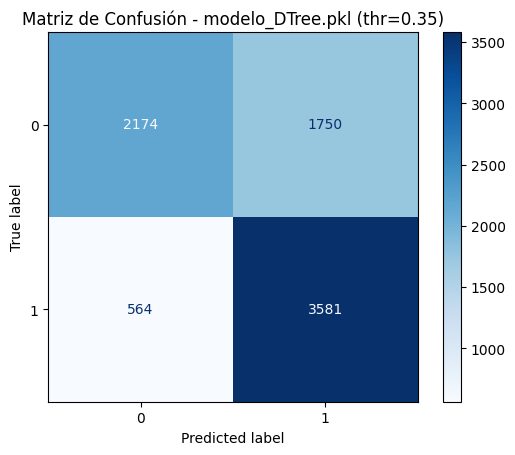

Reporte de clasificación para: modelo_DTree.pkl
              precision    recall  f1-score   support

           0       0.79      0.55      0.65      3924
           1       0.67      0.86      0.76      4145

    accuracy                           0.71      8069
   macro avg       0.73      0.71      0.70      8069
weighted avg       0.73      0.71      0.71      8069

------------------------------------------------------------


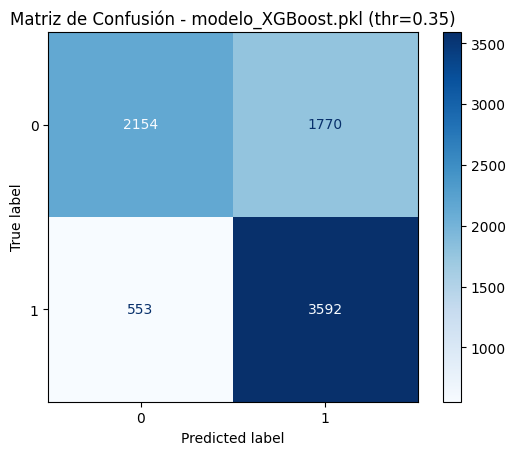

Reporte de clasificación para: modelo_XGBoost.pkl
              precision    recall  f1-score   support

           0       0.80      0.55      0.65      3924
           1       0.67      0.87      0.76      4145

    accuracy                           0.71      8069
   macro avg       0.73      0.71      0.70      8069
weighted avg       0.73      0.71      0.70      8069

------------------------------------------------------------


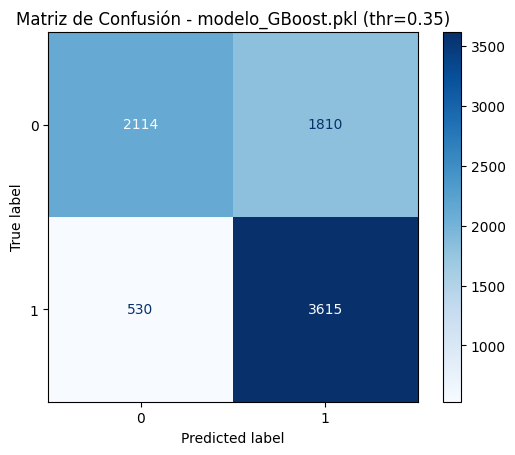

Reporte de clasificación para: modelo_GBoost.pkl
              precision    recall  f1-score   support

           0       0.80      0.54      0.64      3924
           1       0.67      0.87      0.76      4145

    accuracy                           0.71      8069
   macro avg       0.73      0.71      0.70      8069
weighted avg       0.73      0.71      0.70      8069

------------------------------------------------------------


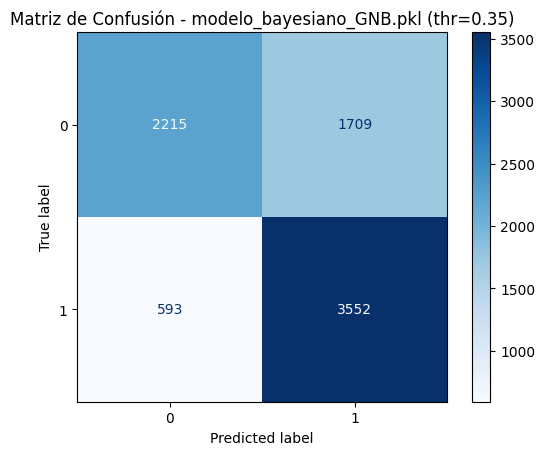

Reporte de clasificación para: modelo_bayesiano_GNB.pkl
              precision    recall  f1-score   support

           0       0.79      0.56      0.66      3924
           1       0.68      0.86      0.76      4145

    accuracy                           0.71      8069
   macro avg       0.73      0.71      0.71      8069
weighted avg       0.73      0.71      0.71      8069

------------------------------------------------------------


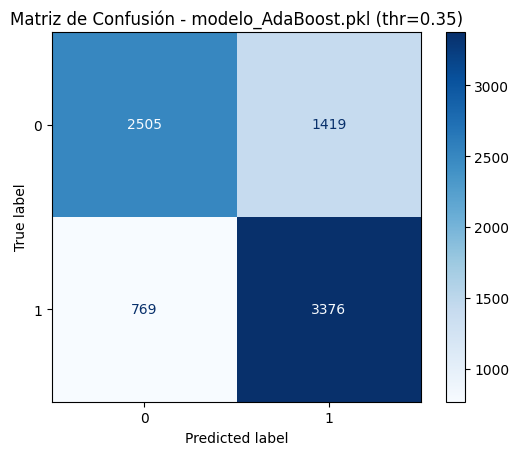

Reporte de clasificación para: modelo_AdaBoost.pkl
              precision    recall  f1-score   support

           0       0.77      0.64      0.70      3924
           1       0.70      0.81      0.76      4145

    accuracy                           0.73      8069
   macro avg       0.73      0.73      0.73      8069
weighted avg       0.73      0.73      0.73      8069

------------------------------------------------------------


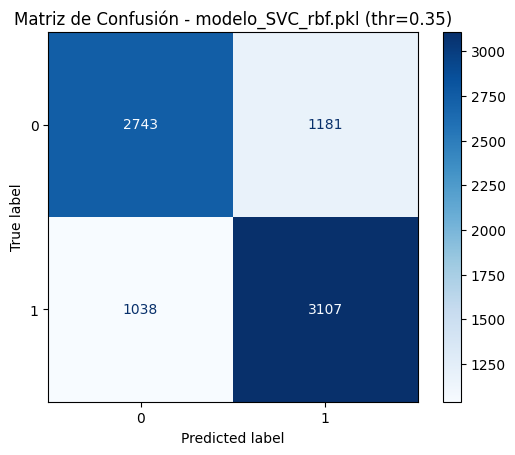

Reporte de clasificación para: modelo_SVC_rbf.pkl
              precision    recall  f1-score   support

           0       0.73      0.70      0.71      3924
           1       0.72      0.75      0.74      4145

    accuracy                           0.72      8069
   macro avg       0.73      0.72      0.72      8069
weighted avg       0.73      0.72      0.72      8069

------------------------------------------------------------


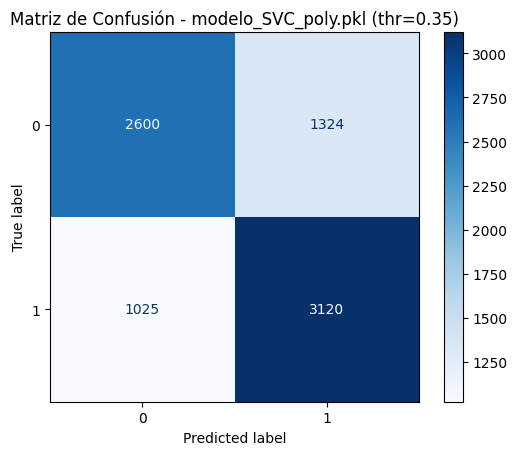

Reporte de clasificación para: modelo_SVC_poly.pkl
              precision    recall  f1-score   support

           0       0.72      0.66      0.69      3924
           1       0.70      0.75      0.73      4145

    accuracy                           0.71      8069
   macro avg       0.71      0.71      0.71      8069
weighted avg       0.71      0.71      0.71      8069

------------------------------------------------------------


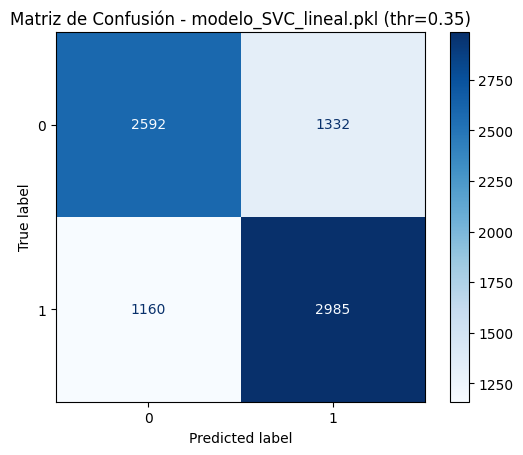

Reporte de clasificación para: modelo_SVC_lineal.pkl
              precision    recall  f1-score   support

           0       0.69      0.66      0.68      3924
           1       0.69      0.72      0.71      4145

    accuracy                           0.69      8069
   macro avg       0.69      0.69      0.69      8069
weighted avg       0.69      0.69      0.69      8069

------------------------------------------------------------


In [197]:
threshold = 0.35

for i, row in dr.sort_values(by='f1_score', ascending=False).iterrows():
    model_name = row['model']
    modelo_cargado = load(model_name)

    Xp_temp = Xp[modelo_cargado.feature_names_in_]

    # Usar probabilidades
    if hasattr(modelo_cargado, "predict_proba"):
        y_prob = modelo_cargado.predict_proba(Xp_temp)[:,1]
        y_pred = (y_prob > threshold).astype(int)
    else:
        y_pred = modelo_cargado.predict(Xp_temp)

    cm = confusion_matrix(yp, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(yp))
    disp.plot(cmap='Blues')
    plt.title(f"Matriz de Confusión - {model_name} (thr={threshold})")
    plt.show()

    print(f"Reporte de clasificación para: {model_name}")
    print(classification_report(yp, y_pred))
    print("-" * 60)